# Libraries and functions

In [3]:
import pickle

import matplotlib.pyplot as plt
import healpy as hp
import numpy as np

from pysimulators.interfaces.healpy import HealpixConvolutionGaussianOperator

In [4]:
def inspect_maps(file):
    data = pickle.load(open(file, "rb"))

    nus = data["nus"]
    Nrec = nus.shape[0] - 7

    maps_input = data["maps_in_convolved"]
    maps_rec = data["maps"][:Nrec]
    maps_res = maps_input - maps_rec
    maps_noise = data['maps_noise'][:Nrec]

    center = data["center"]
    seenpix = data["seenpix"]
    convergence = data["convergence"]
    coverage = data["coverage"]
    parameters = data["parameters"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    hp.mollview(coverage, title='Coverage', cmap='Spectral_r', fig=fig.number, sub=(1, 2, 1))
    plt.subplot(1, 2, 1).axis('off')

    axes[1].plot(convergence)
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Convergence")
    axes[1].set_title("PCG Convergence")
    axes[1].set_yscale("log")
    axes[1].set_ylim(1e-8, 1e0)
    axes[1].grid()

    plt.subplots_adjust(wspace=0.4)
    plt.show()

    
    STOKES = ["I", "Q", "U"]

    maps_input[:, ~seenpix, :] = hp.UNSEEN
    maps_rec[:, ~seenpix, :] = hp.UNSEEN
    maps_res[:, ~seenpix, :] = hp.UNSEEN

    istk = 0
    n = 2
    # sigma_input = np.std(maps_input[:, seenpix, istk], axis=0)
    # sigma_rec = np.std(maps_rec[:, seenpix, istk], axis=0)
    # sigma_res = np.std(maps_rec[:, seenpix, istk] - maps_input[:, seenpix, istk], axis=0)

    reso = 15

    k = 0

    plt.figure(figsize=(20, 10))
    for inu in range(Nrec):
        hp.gnomview((maps_input[inu, :, istk]), rot=center,
                            reso=reso,
                            notext=True,
                            title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} input",  
                            cmap="jet",
                            # min = - n * sigma_input[inu],
                            # max = n * sigma_input[inu],
                            sub=(Nrec, 3, k + 1))
        
        hp.gnomview((maps_rec[inu, :, istk]), rot=center,
                            reso=reso,
                            notext=True,
                            title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Output",
                            cmap="jet",
                            # min = - n * sigma_rec[inu],
                            # max = n * sigma_rec[inu],
                            sub=(Nrec, 3, k + 2))
        
        hp.gnomview(maps_res[inu, :, istk], rot=center,
                            reso=reso,
                            notext=True,
                            title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Residual",
                            cmap="jet",
                            # min = - n * sigma_res[inu],
                            # max = n * sigma_res[inu],
                            sub=(Nrec, 3, k + 3))
        k += 3

    del data


def load_maps(file, plot=False):
    data = pickle.load(open(file, "rb"))

    nus = data["nus"]
    Nrec = nus.shape[0] - 7

    maps_input = data["maps_in_convolved"]
    maps_rec = data["maps"][:Nrec]
    maps_res = maps_input - maps_rec
    maps_noise = data['maps_noise'][:Nrec]

    center = data["center"]
    seenpix = data["seenpix"]

    del data

    maps_input[:, ~seenpix, :] = hp.UNSEEN
    maps_rec[:, ~seenpix, :] = hp.UNSEEN
    maps_res[:, ~seenpix, :] = hp.UNSEEN

    if plot==True:
        STOKES = ["I", "Q", "U"]

        istk = 0
        n = 2
        # sigma_input = np.std(maps_input[:, seenpix, istk], axis=0)
        # sigma_rec = np.std(maps_rec[:, seenpix, istk], axis=0)
        # sigma_res = np.std(maps_rec[:, seenpix, istk] - maps_input[:, seenpix, istk], axis=0)

        reso = 15

        k = 0

        plt.figure(figsize=(20, 10))
        for inu in range(Nrec):
            hp.gnomview((maps_input[inu, :, istk]), rot=center,
                                reso=reso,
                                notext=True,
                                title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} input",  
                                cmap="jet",
                                # min = - n * sigma_input[inu],
                                # max = n * sigma_input[inu],
                                sub=(Nrec, 3, k + 1))
            
            hp.gnomview((maps_rec[inu, :, istk]), rot=center,
                                reso=reso,
                                notext=True,
                                title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Output",
                                cmap="jet",
                                # min = - n * sigma_rec[inu],
                                # max = n * sigma_rec[inu],
                                sub=(Nrec, 3, k + 2))
            
            hp.gnomview(maps_res[inu, :, istk], rot=center,
                                reso=reso,
                                notext=True,
                                title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Residual",
                                cmap="jet",
                                # min = - n * sigma_res[inu],
                                # max = n * sigma_res[inu],
                                sub=(Nrec, 3, k + 3))
            k += 3

    return maps_input[:,:,0], maps_rec[:,:,0], maps_res[:,:,0], center, seenpix

    

# On noise computation

L'idea è quella di vedere se la mappe che si ottengono aggiungendo alle mappe di input il rumore simulato indipendentemente sono equivalenti alle mappe simulate tenendo conto sia del cielo che del rumore

## Noise + sky

1 anno di simulazione con random pointing e noise riscalato

In [2]:
data = pickle.load(open("/media/mattia/Hard Disk/data/test_noise/noise_sky.pkl", "rb"))

In [3]:
nus = data["nus"]
Nrec = nus.shape[0] - 7

maps_input = data["maps_in_convolved"]
maps_rec = data["maps"][:Nrec]
maps_res = maps_input - maps_rec
maps_noise = data['maps_noise'][:Nrec]

center = data["center"]
seenpix = data["seenpix"]
convergence = data["convergence"]
parameters = data["parameters"]
coverage = data['coverage']

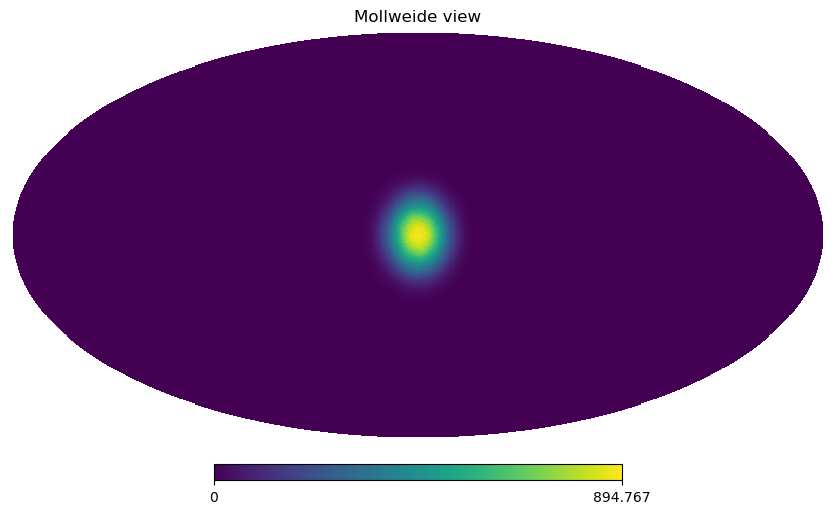

In [4]:
hp.mollview(coverage)

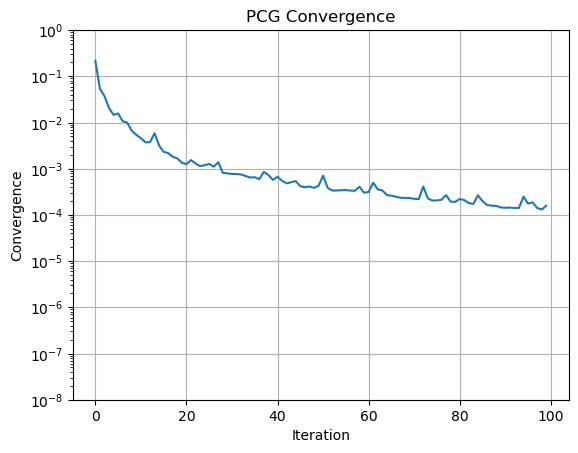

In [5]:
plt.plot(convergence)
plt.xlabel("Iteration")
plt.ylabel("Convergence")
plt.title("PCG Convergence")
plt.yscale("log")
plt.ylim(1e-8, 1e0)
plt.grid()
plt.show()

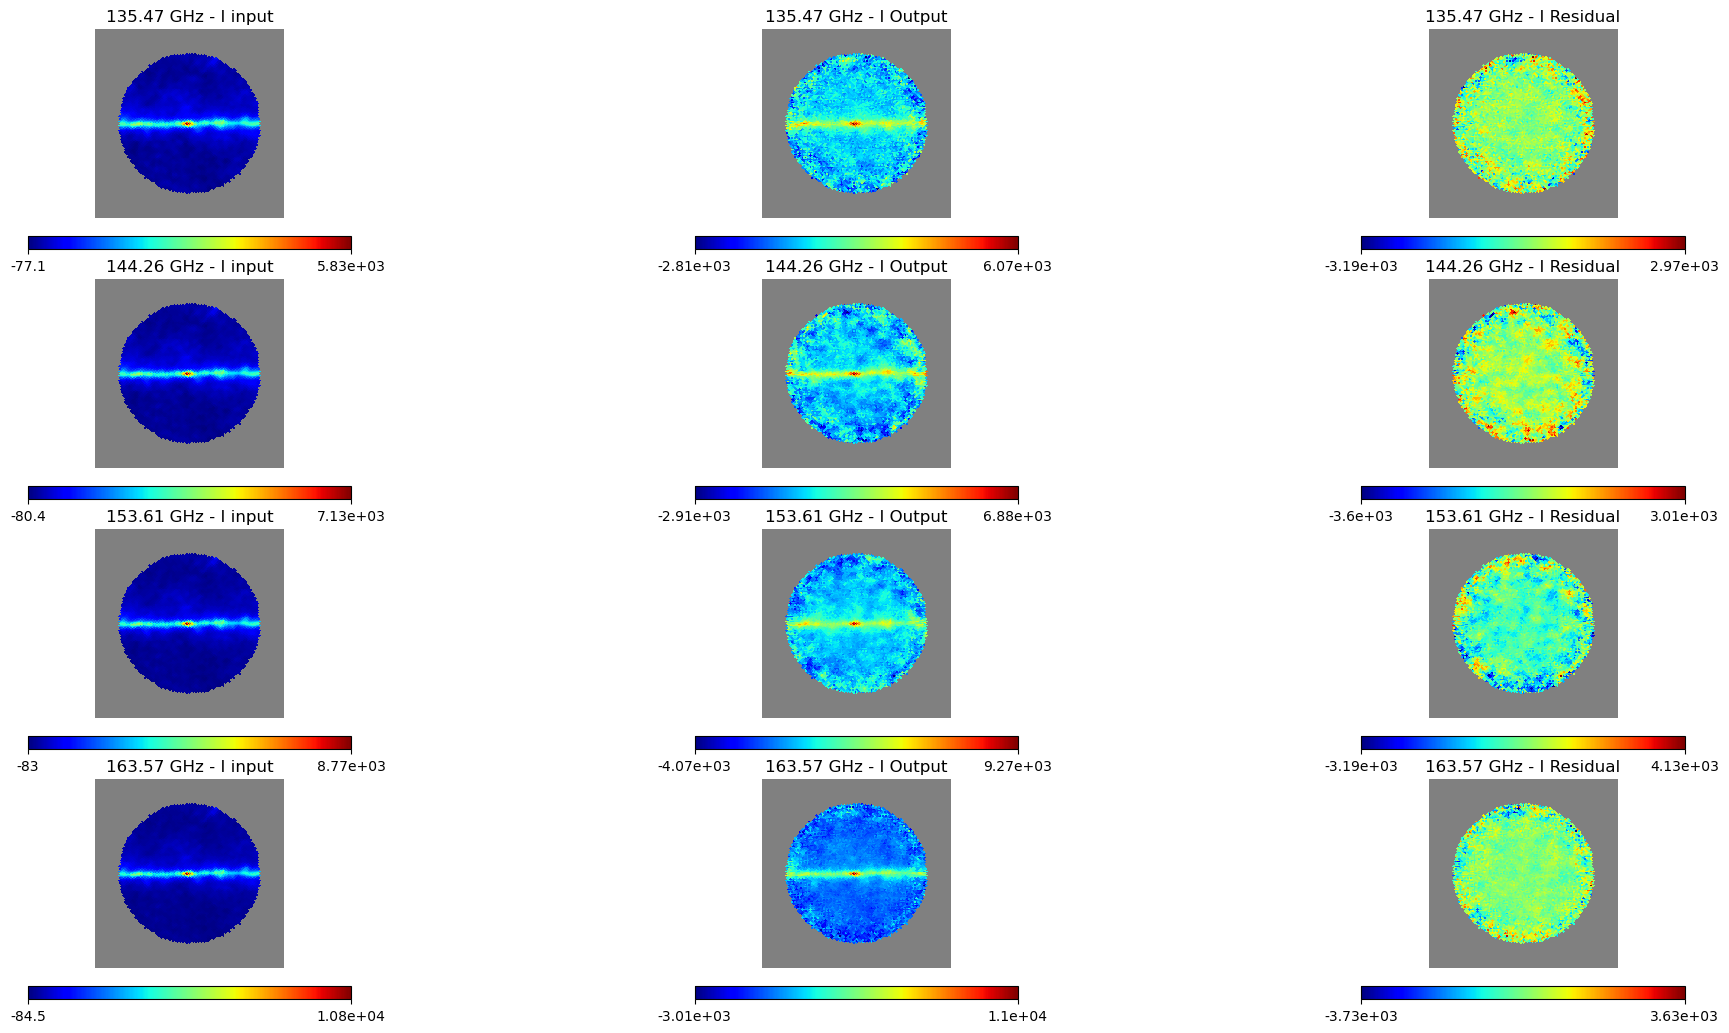

In [6]:
STOKES = ["I", "Q", "U"]

maps_input[:, ~seenpix, :] = hp.UNSEEN
maps_rec[:, ~seenpix, :] = hp.UNSEEN
maps_res[:, ~seenpix, :] = hp.UNSEEN

istk = 0
n = 2
# sigma_input = np.std(maps_input[:, seenpix, istk], axis=0)
# sigma_rec = np.std(maps_rec[:, seenpix, istk], axis=0)
# sigma_res = np.std(maps_rec[:, seenpix, istk] - maps_input[:, seenpix, istk], axis=0)

reso = 15

k = 0

plt.figure(figsize=(20, 10))
for inu in range(Nrec):
    hp.gnomview((maps_input[inu, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(Nrec, 3, k + 1))
    
    hp.gnomview((maps_rec[inu, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(Nrec, 3, k + 2))
    
    hp.gnomview(maps_res[inu, :, istk], rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Residual",
                        cmap="jet",
                        # min = - n * sigma_res[inu],
                        # max = n * sigma_res[inu],
                        sub=(Nrec, 3, k + 3))
    k += 3
    #plt.savefig('/home/mattia/Desktop/1sec.png')

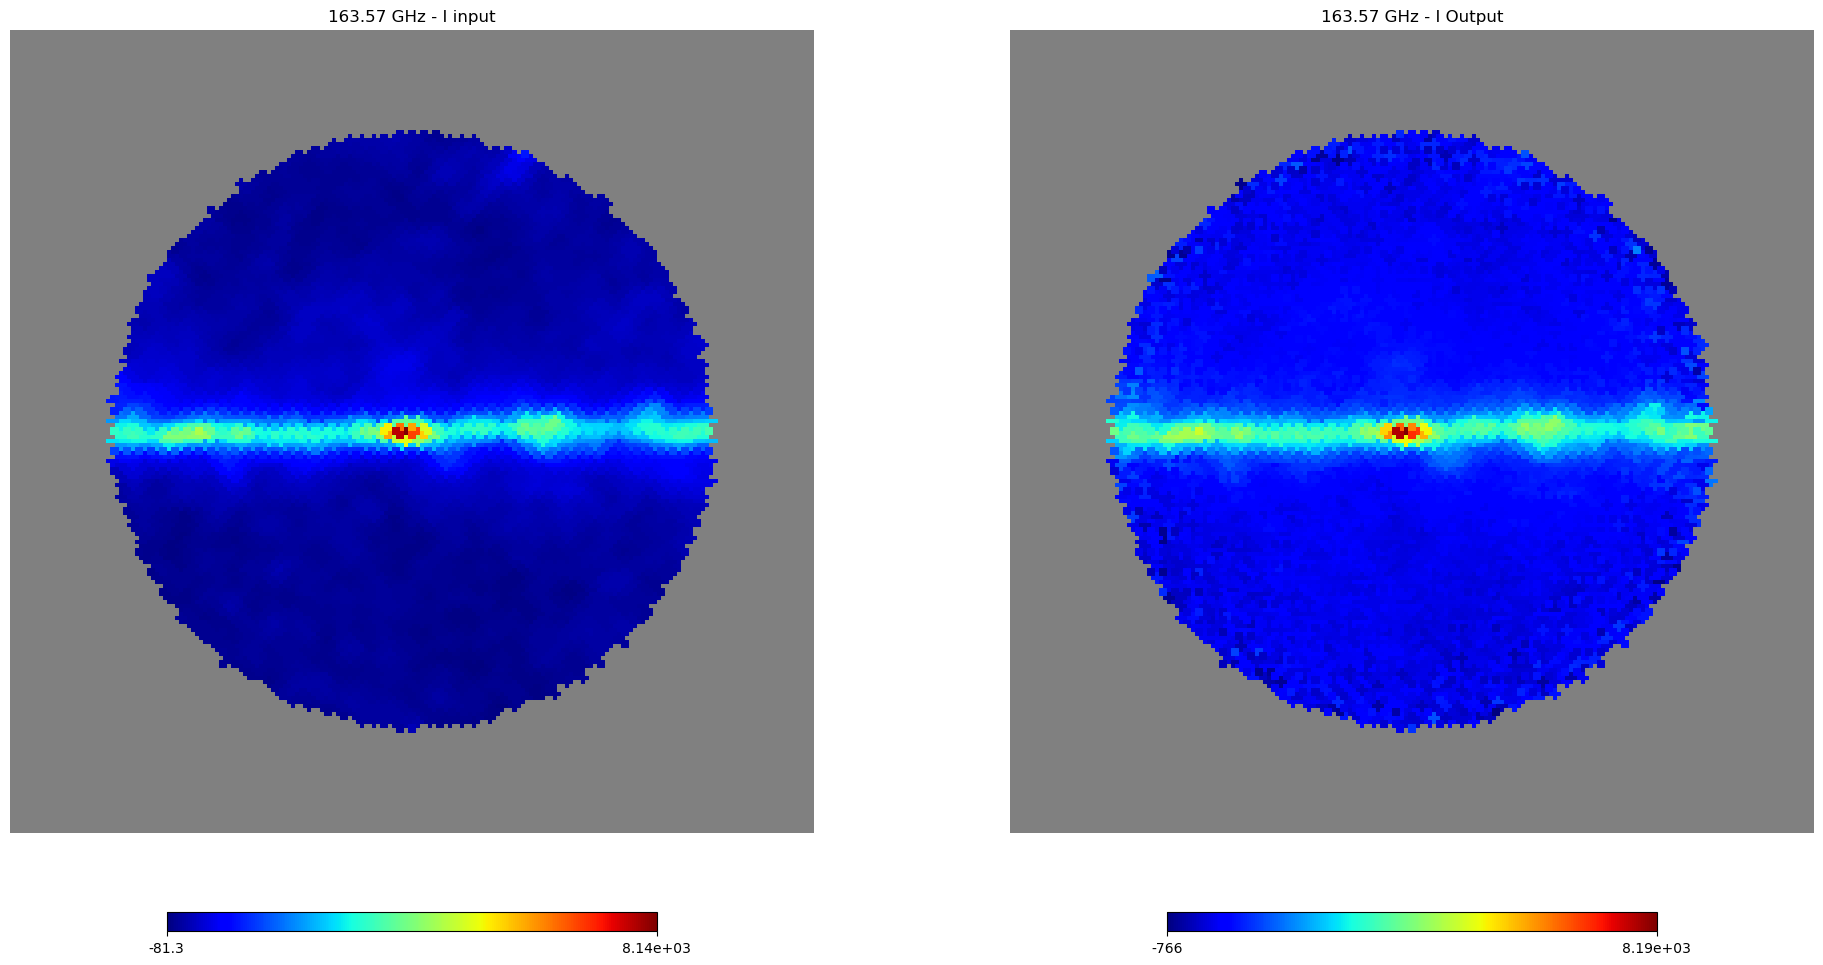

In [7]:
maps_input_mean = np.mean(maps_input[:,:,0], axis=0)
maps_rec_mean = np.mean(maps_rec[:,:,0], axis=0)

plt.figure(figsize=(20, 10))
hp.gnomview((maps_input_mean), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(1, 2, 1)
    )
    
hp.gnomview((maps_rec_mean), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(1, 2, 2)
    )

In [8]:
days = 365
pointings = 800
factor = days*24 / (8000/60/60)
factor

3942.0

In [9]:
brightest_pix_input = np.argmax(maps_input_mean)   # indice del pixel con valore massimo nelle mappe di input
brightest_val = maps_rec_mean[brightest_pix_input]
brightest_val_true = maps_input_mean[brightest_pix_input]

print('coverage pixel centrale', coverage[brightest_pix_input]*factor)
print('Pixel centrale mappa input', brightest_val_true)
print('Pixel centrale mappe ricostruita', brightest_val)
print('SNR', brightest_val_true/(brightest_val-brightest_val_true))

coverage pixel centrale 3504707.3668616177
Pixel centrale mappa input 8140.484210744878
Pixel centrale mappe ricostruita 8193.178939547051
SNR 154.48384299131374


## Noise

In [10]:
data_noise = pickle.load(open("/media/mattia/Hard Disk/data/test_noise/noise.pkl", "rb"))

In [11]:
nus = data_noise["nus"]
Nrec = nus.shape[0] - 7

maps_input_noise = data_noise["maps_in_convolved"]
maps_rec_noise = data_noise["maps"][:Nrec]
maps_res_noise = maps_input_noise - maps_rec_noise

center = data_noise["center"]
seenpix = data_noise["seenpix"]
convergence_noise = data_noise["convergence"]
parameters_noise = data_noise["parameters"]

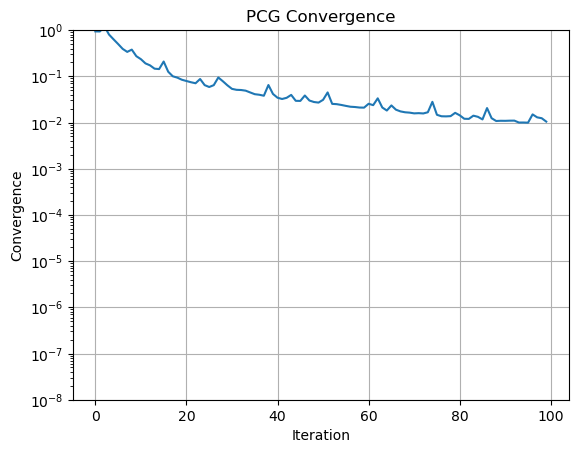

In [12]:
plt.plot(convergence_noise)
plt.xlabel("Iteration")
plt.ylabel("Convergence")
plt.title("PCG Convergence")
plt.yscale("log")
plt.ylim(1e-8, 1e0)
plt.grid()
plt.show()

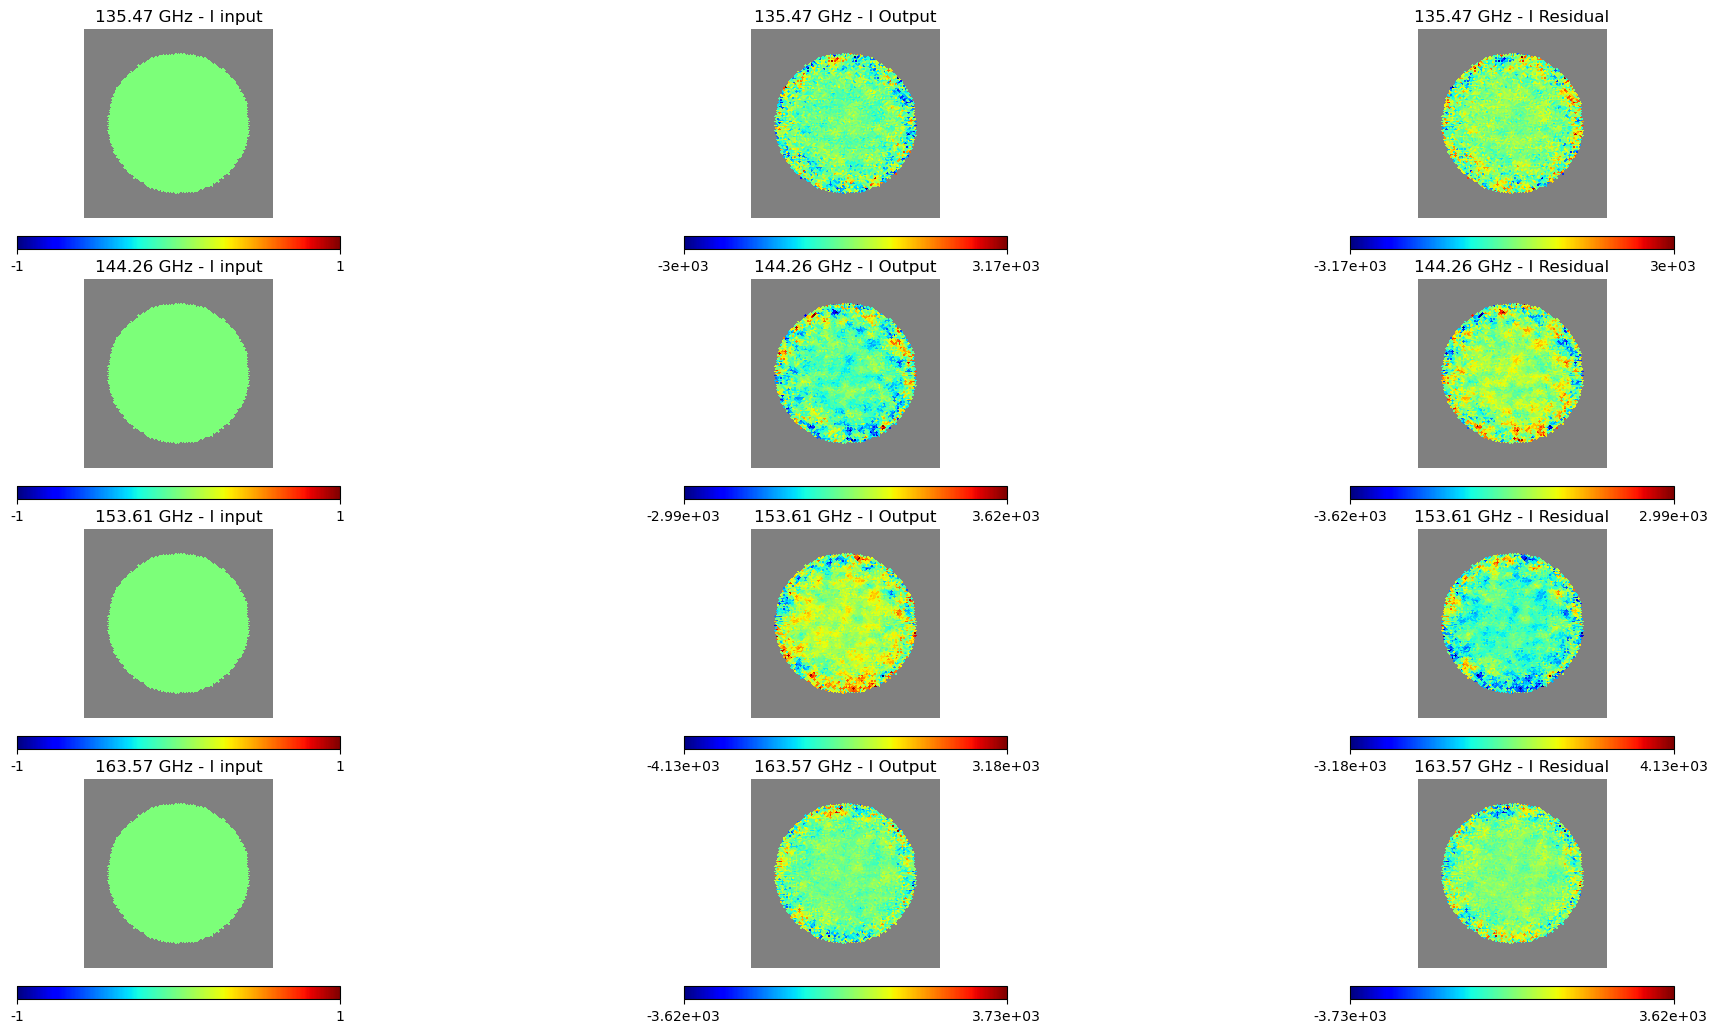

In [13]:
STOKES = ["I", "Q", "U"]

maps_input_noise[:, ~seenpix, :] = hp.UNSEEN
maps_rec_noise[:, ~seenpix, :] = hp.UNSEEN
maps_res_noise[:, ~seenpix, :] = hp.UNSEEN

istk = 0
n = 2
# sigma_input = np.std(maps_input[:, seenpix, istk], axis=0)
# sigma_rec = np.std(maps_rec[:, seenpix, istk], axis=0)
# sigma_res = np.std(maps_rec[:, seenpix, istk] - maps_input[:, seenpix, istk], axis=0)

reso = 15

k = 0

plt.figure(figsize=(20, 10))
for inu in range(Nrec):
    hp.gnomview((maps_input_noise[inu, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(Nrec, 3, k + 1))
    
    hp.gnomview((maps_rec_noise[inu, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(Nrec, 3, k + 2))
    
    hp.gnomview(maps_res_noise[inu, :, istk], rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Residual",
                        cmap="jet",
                        # min = - n * sigma_res[inu],
                        # max = n * sigma_res[inu],
                        sub=(Nrec, 3, k + 3))
    k += 3
    #plt.savefig('/home/mattia/Desktop/1sec.png')

## Aggiungo il noise calcolato separatamente alle mappe di input

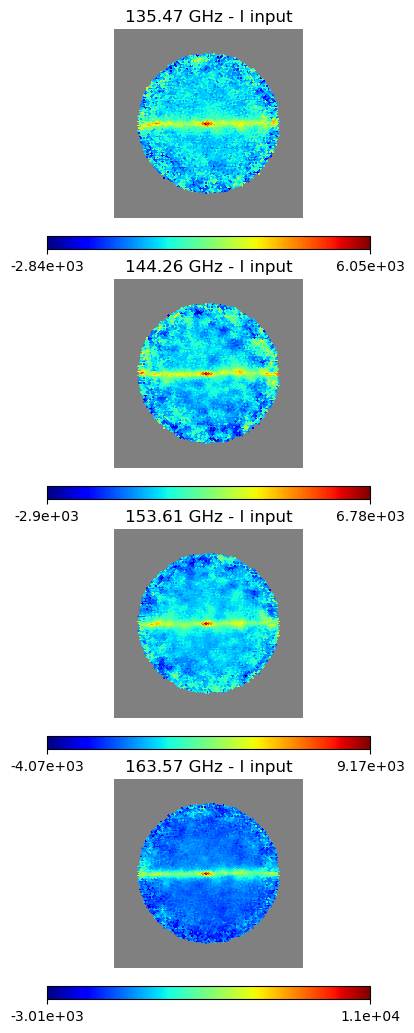

In [14]:
STOKES = ["I", "Q", "U"]

maps_sky_noise = maps_input + maps_rec_noise
maps_sky_noise[:, ~seenpix, :] = hp.UNSEEN

istk = 0
n = 2
# sigma_input = np.std(maps_input[:, seenpix, istk], axis=0)
# sigma_rec = np.std(maps_rec[:, seenpix, istk], axis=0)
# sigma_res = np.std(maps_rec[:, seenpix, istk] - maps_input[:, seenpix, istk], axis=0)

reso = 15

k = 0

plt.figure(figsize=(20, 10))
for inu in range(Nrec):
    hp.gnomview((maps_sky_noise[inu, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(Nrec, 3, k + 1))
    
    k += 3
    #plt.savefig('/home/mattia/Desktop/1sec.png')

Non si nota una differenza sostanziale!

# On the differences between the scanning strategy and the random pointing

L'idea è quella di andare a vedere se ci sono differenze sul livello di rumore tra le mappe simulate con il random pointing e quelle con la scanning strategy. C'è da tenere in considerazione che con la scanning strategy si osserva per circa il 25% del tempo quindi un'osservazione con scanning strategy da un anno corrisponde ad una osservazione continua con radonm pointing di 3 mesi

## Noise + sky 3 months

Simulazione con random pointing di 3 mesi continuim

In [15]:
data = pickle.load(open("/media/mattia/Hard Disk/data/test_noise/noise_sky_3months.pkl", "rb"))

In [16]:
nus = data["nus"]
Nrec = nus.shape[0] - 7

maps_input = data["maps_in_convolved"]
maps_rec = data["maps"][:Nrec]
maps_res = maps_input - maps_rec
maps_noise = data['maps_noise'][:Nrec]

center = data["center"]
seenpix = data["seenpix"]
convergence = data["convergence"]
coverage = data["coverage"]
parameters = data["parameters"]

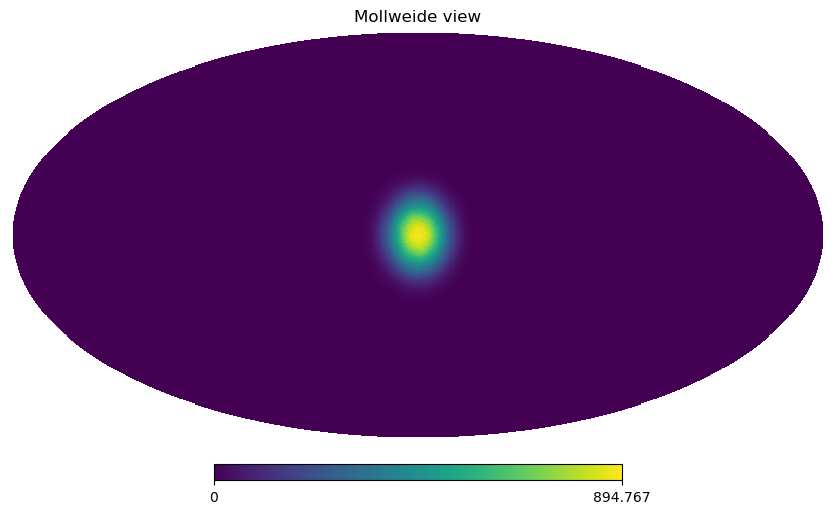

In [17]:
hp.mollview(coverage)

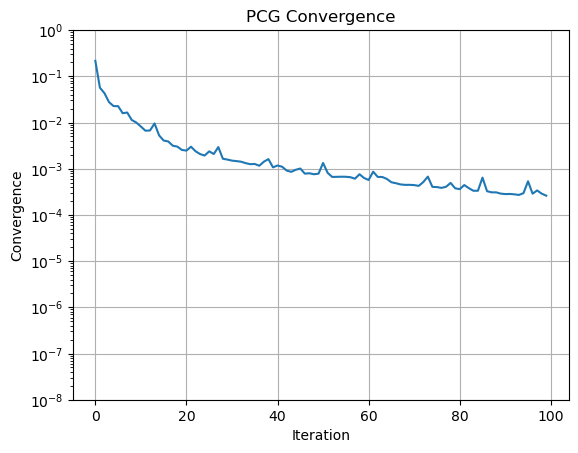

In [18]:
plt.plot(convergence)
plt.xlabel("Iteration")
plt.ylabel("Convergence")
plt.title("PCG Convergence")
plt.yscale("log")
plt.ylim(1e-8, 1e0)
plt.grid()
plt.show()

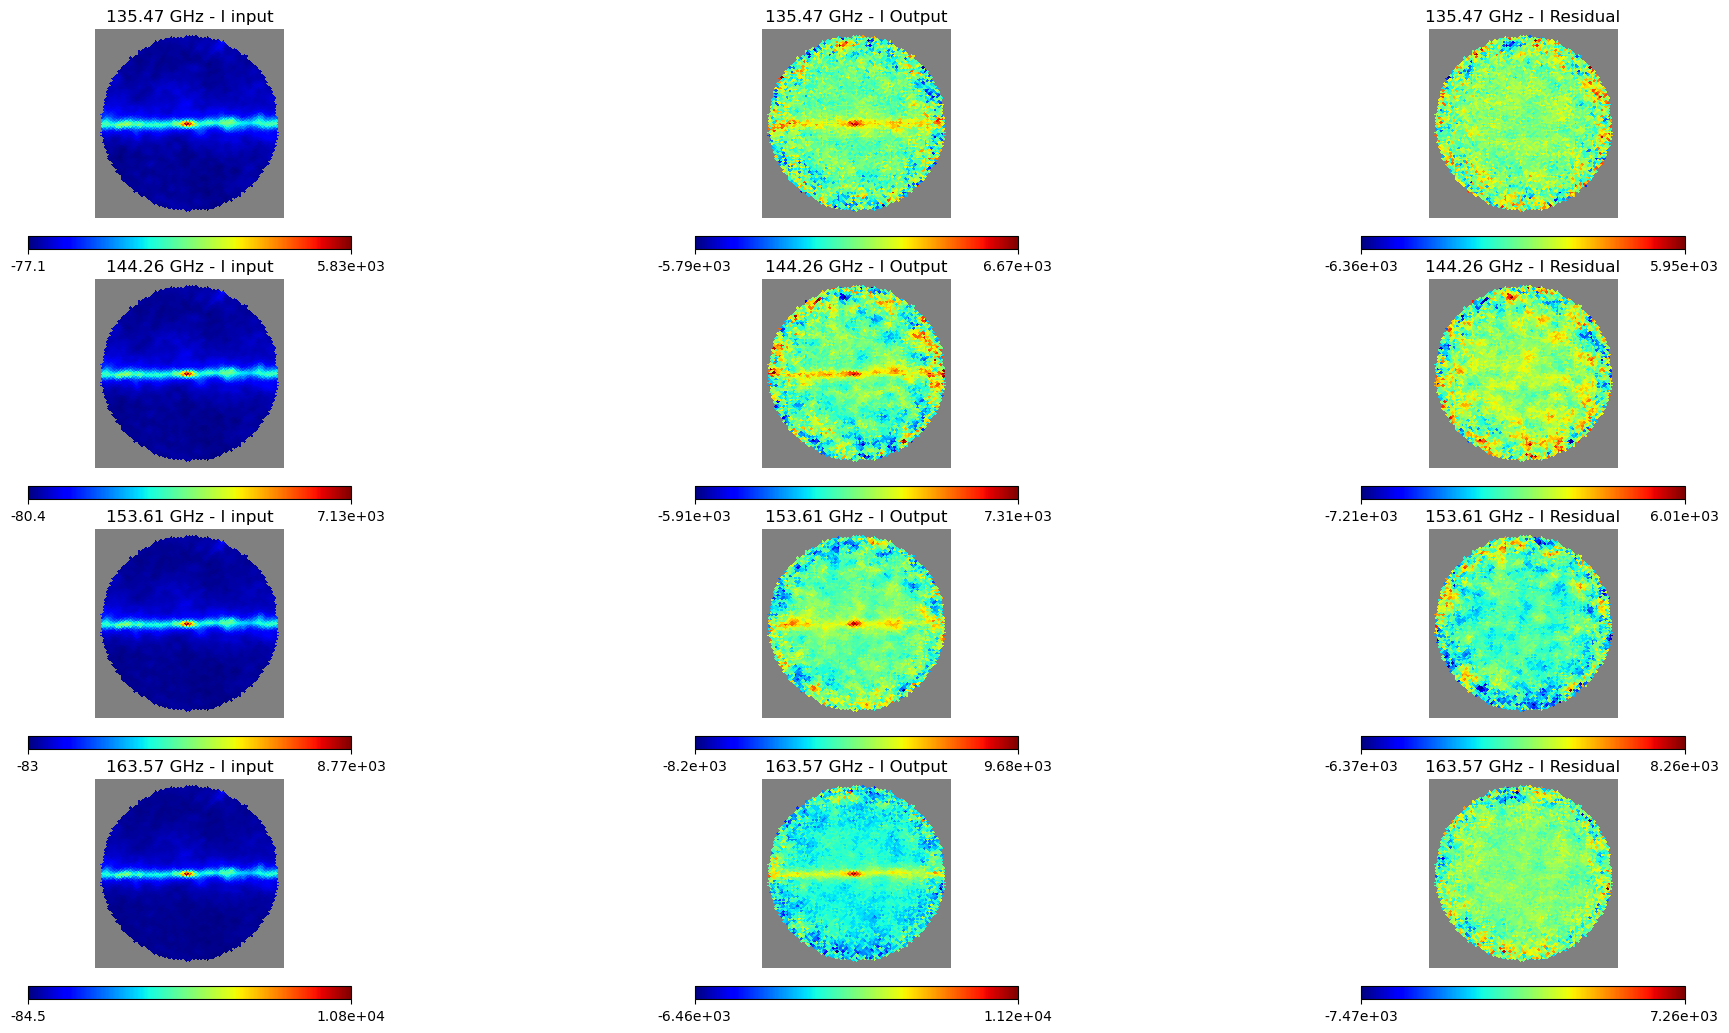

In [19]:
STOKES = ["I", "Q", "U"]

maps_input[:, ~seenpix, :] = hp.UNSEEN
maps_rec[:, ~seenpix, :] = hp.UNSEEN
maps_res[:, ~seenpix, :] = hp.UNSEEN

istk = 0
n = 2
# sigma_input = np.std(maps_input[:, seenpix, istk], axis=0)
# sigma_rec = np.std(maps_rec[:, seenpix, istk], axis=0)
# sigma_res = np.std(maps_rec[:, seenpix, istk] - maps_input[:, seenpix, istk], axis=0)

reso = 12

k = 0

plt.figure(figsize=(20, 10))
for inu in range(Nrec):
    hp.gnomview((maps_input[inu, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(Nrec, 3, k + 1))
    
    hp.gnomview((maps_rec[inu, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(Nrec, 3, k + 2))
    
    hp.gnomview(maps_res[inu, :, istk], rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Residual",
                        cmap="jet",
                        # min = - n * sigma_res[inu],
                        # max = n * sigma_res[inu],
                        sub=(Nrec, 3, k + 3))
    k += 3
    #plt.savefig('/home/mattia/Desktop/1sec.png')

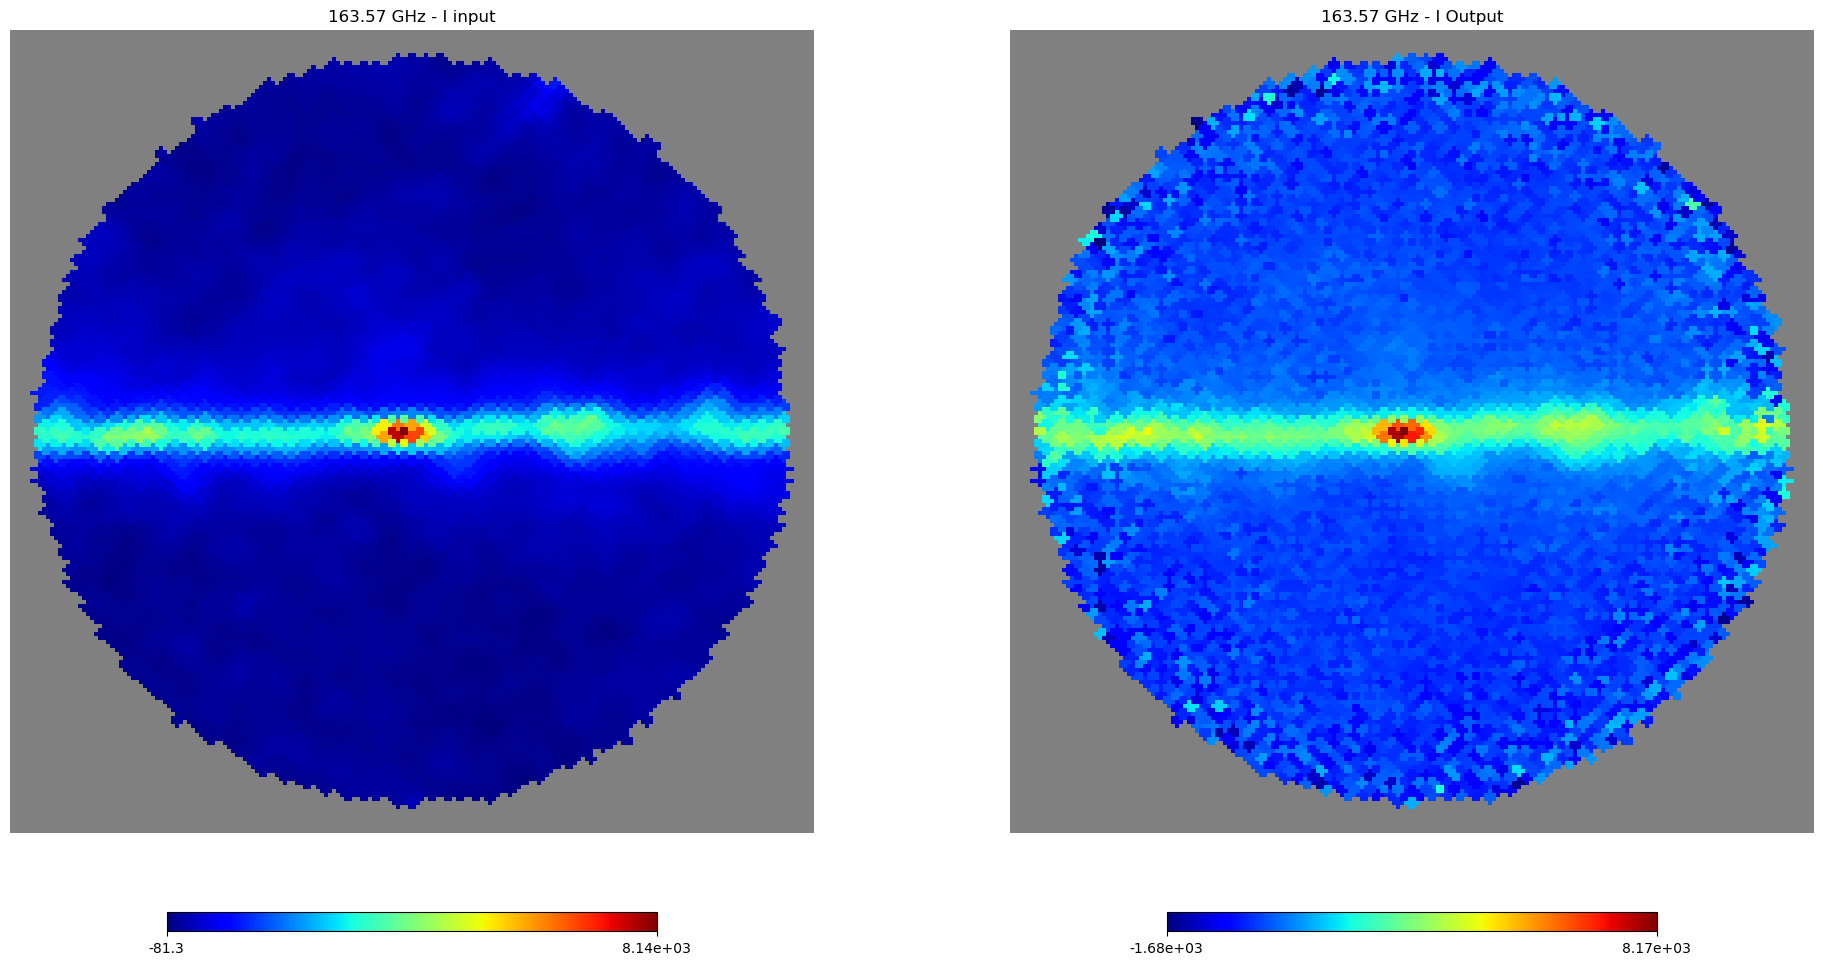

In [20]:
maps_input_mean = np.mean(maps_input[:,:,0], axis=0)
maps_rec_mean = np.mean(maps_rec[:,:,0], axis=0)

plt.figure(figsize=(20, 10))
hp.gnomview((maps_input_mean), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(1,2,1))

    
hp.gnomview((maps_rec_mean), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(1,2,2))
    

Nel random pointing sto utilizzando 8000 puntamenti che vengono ripetuti fino a che si raggiunge la durata dell'osservazione. Quindi la coverage deve essere moltiplicata per un certo fattore

In [21]:
days = 90
pointings = 8000
factor = days*24 / (pointings/60/60)
factor

972.0

In [22]:
brightest_pix_input = np.argmax(maps_input_mean)   # indice del pixel con valore massimo nelle mappe di input
brightest_val = maps_rec_mean[brightest_pix_input]
brightest_val_true = maps_input_mean[brightest_pix_input]

print('coverage pixel centrale', coverage[brightest_pix_input]*factor)
print('Pixel centrale mappa input', brightest_val_true)
print('Pixel centrale mappe ricostruita', brightest_val)
print('SNR', brightest_val_true/(brightest_val-brightest_val_true))

coverage pixel centrale 864174.4192261522
Pixel centrale mappa input 8140.484210744878
Pixel centrale mappe ricostruita 8165.453902467401
SNR 326.01460607548495


Per la scanning strategy si ottiene un SNR di 43, il livello di rumore a parità di puntamenti è molto più alto

## Comparison between simulation of two months with scanning strategy, random pointing and sweeping pointing

### Random pointing 15 days

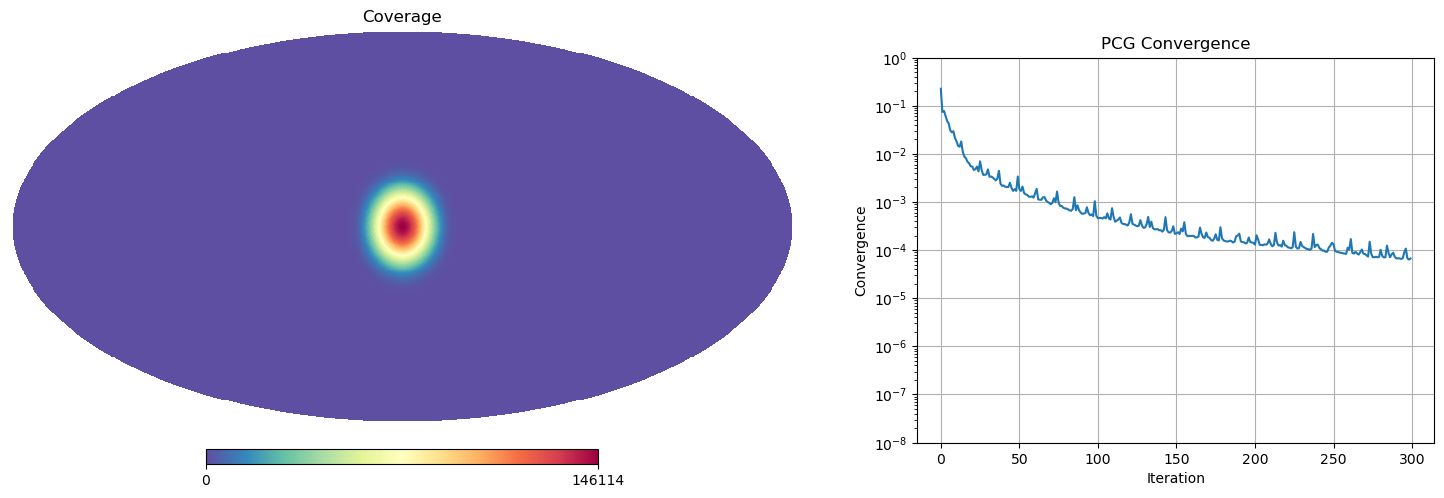

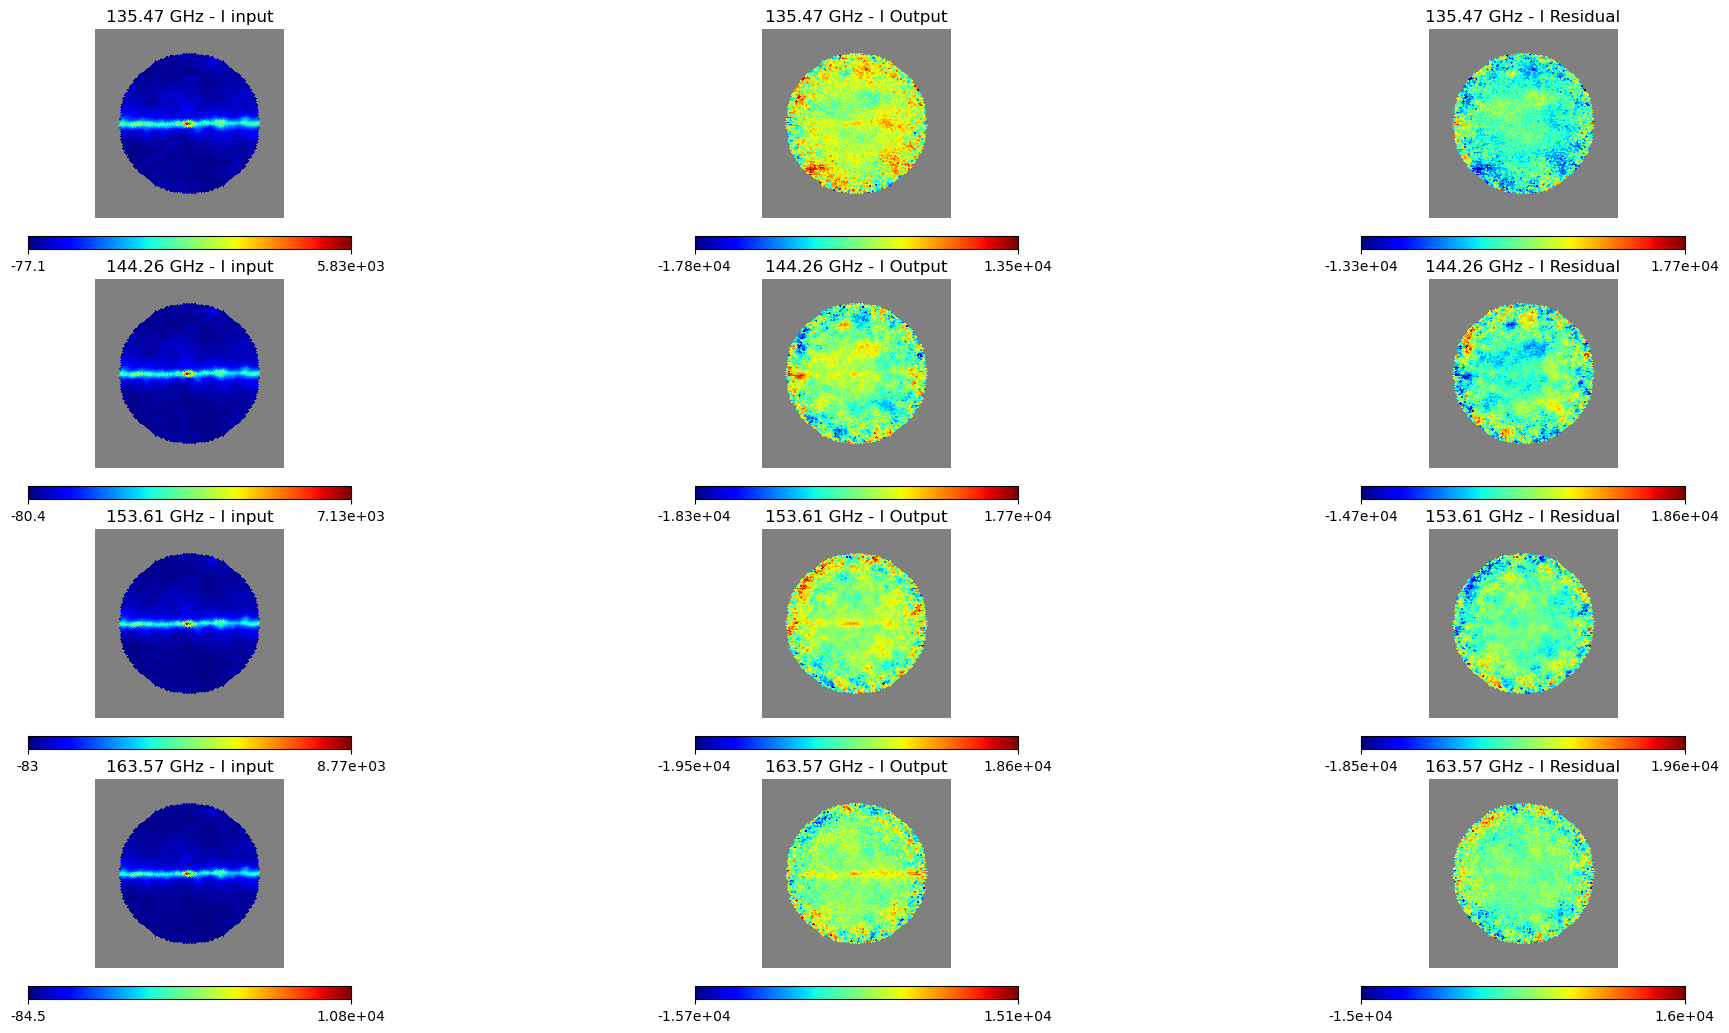

In [3]:
inspect_maps("/media/mattia/Hard Disk/data/test_noise/15days_rp.pkl")

### Random pointing 15 days with rescaled noise

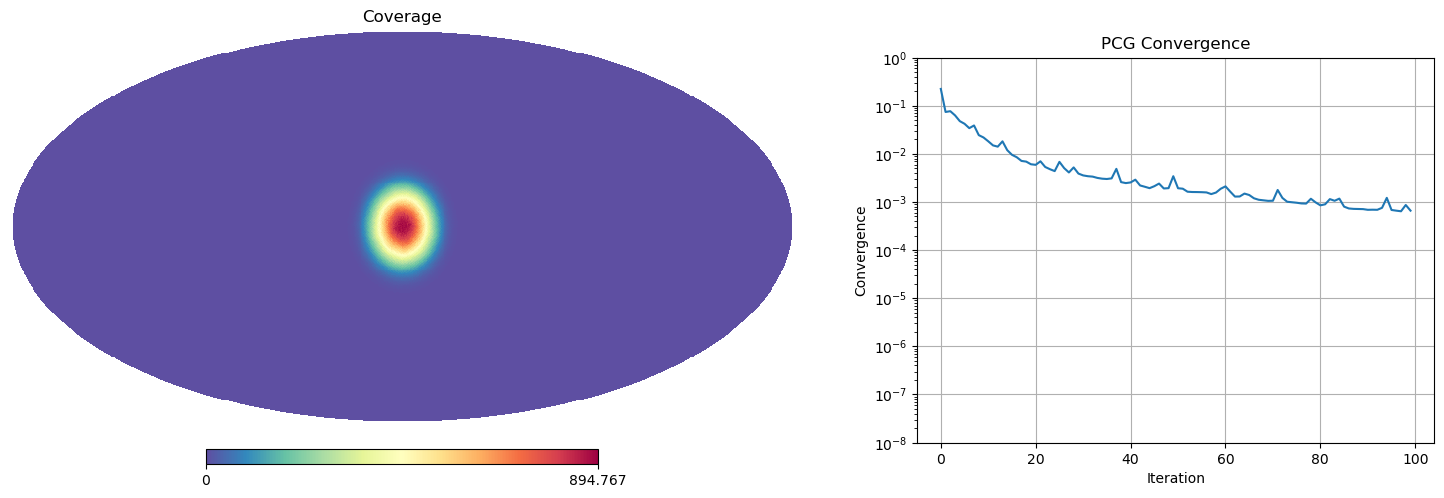

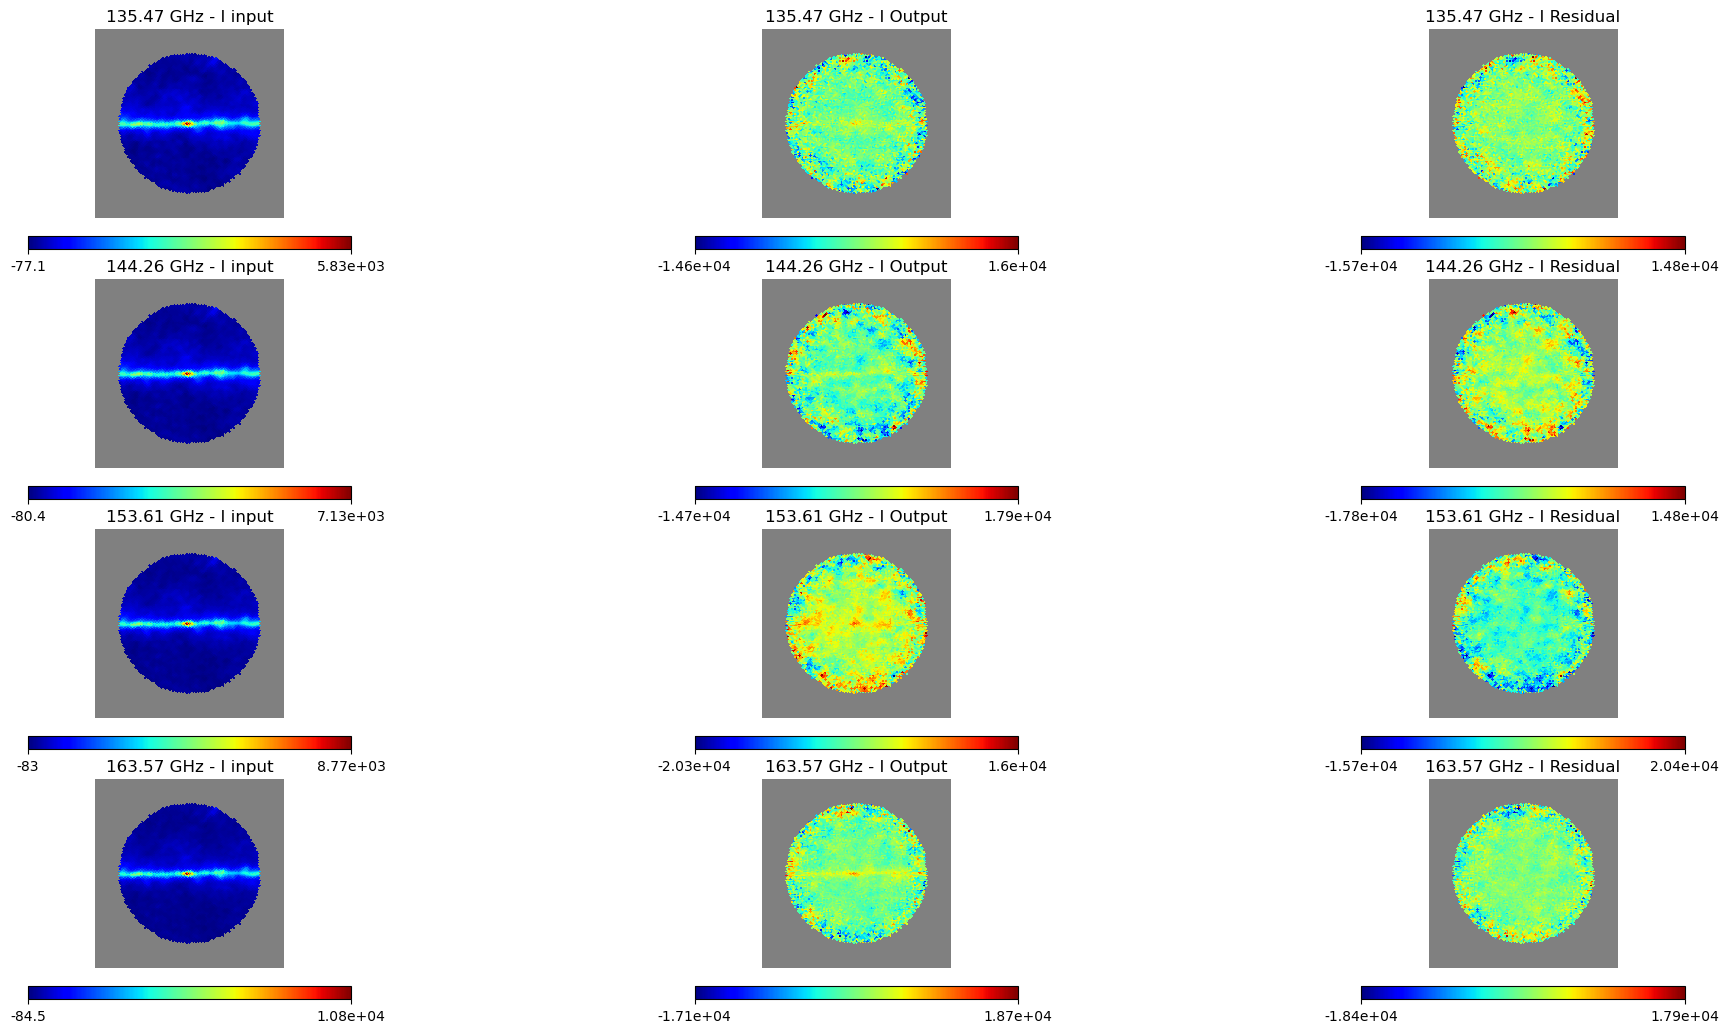

In [ ]:
inspect_maps("/media/mattia/Hard Disk/data/test_noise/noise_sky_15days.pkl")

### Scanning strategy 2 months (15 days effective)

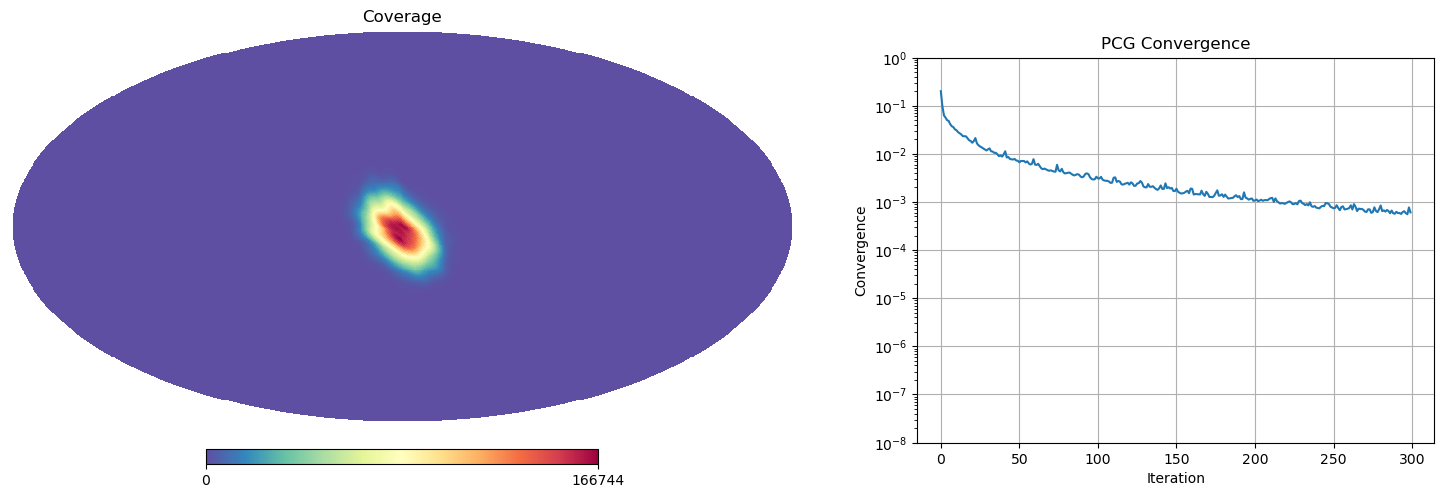

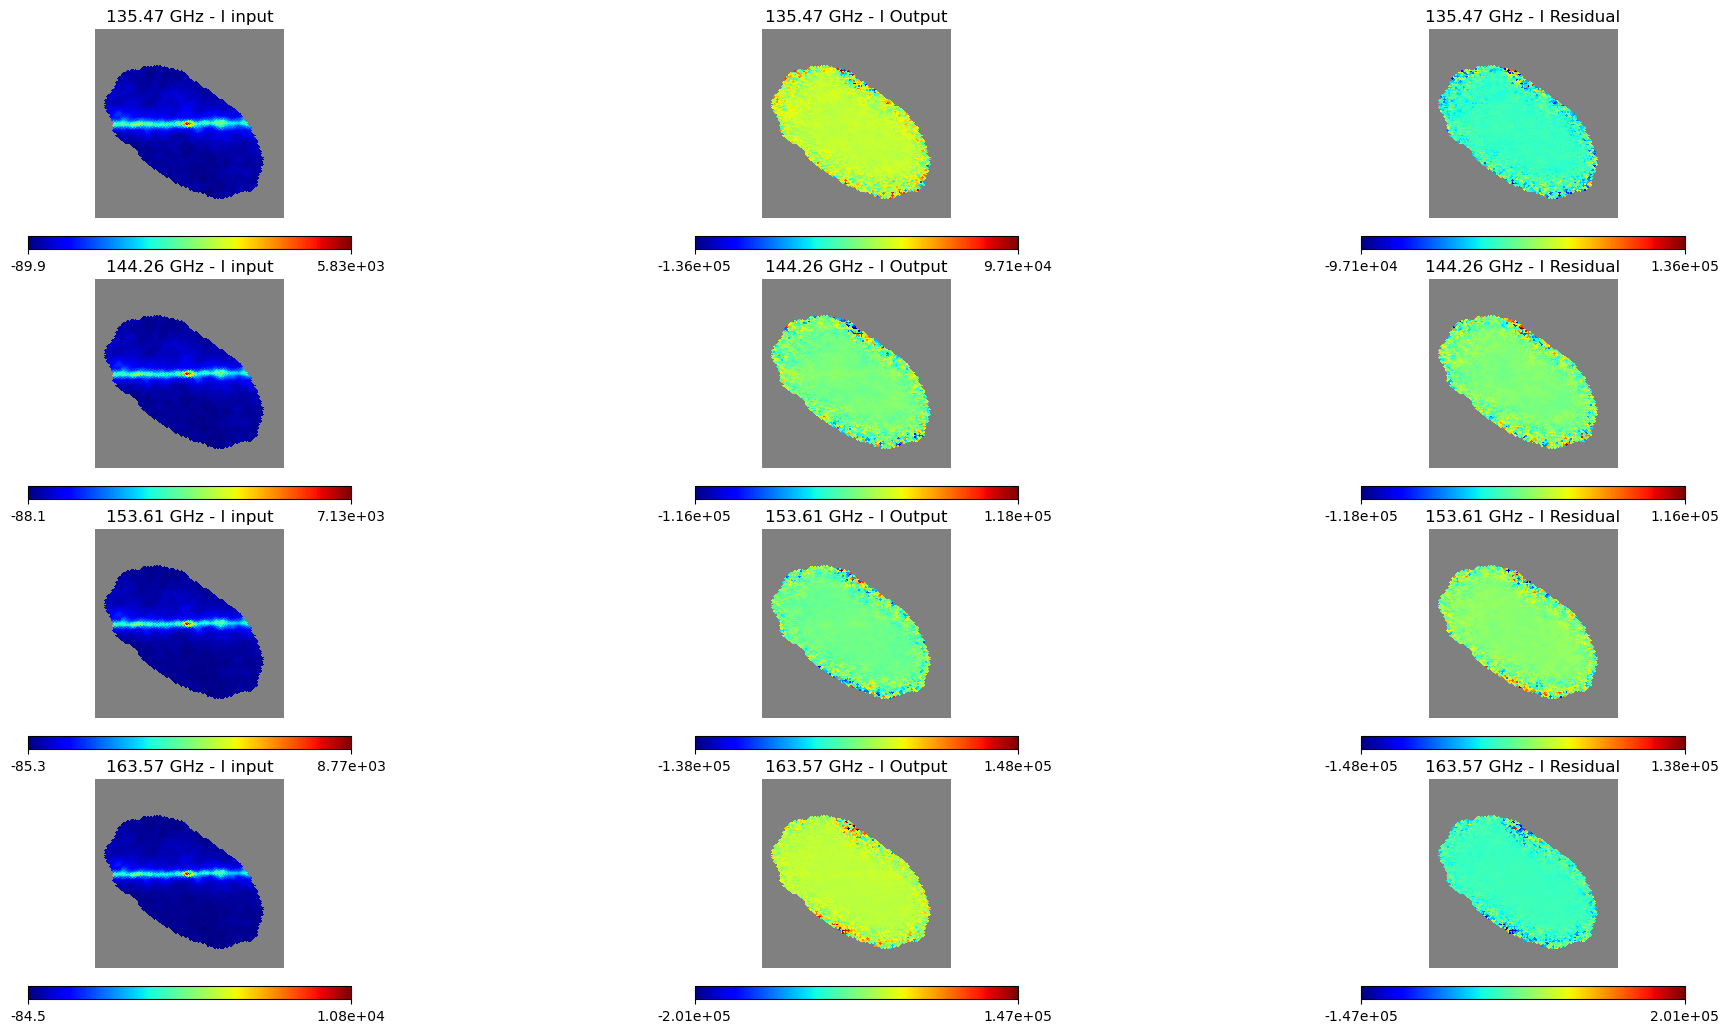

In [ ]:
inspect_maps("/media/mattia/Hard Disk/data/test_noise/15days_ss.pkl")

### Sweeping pointing 15 days

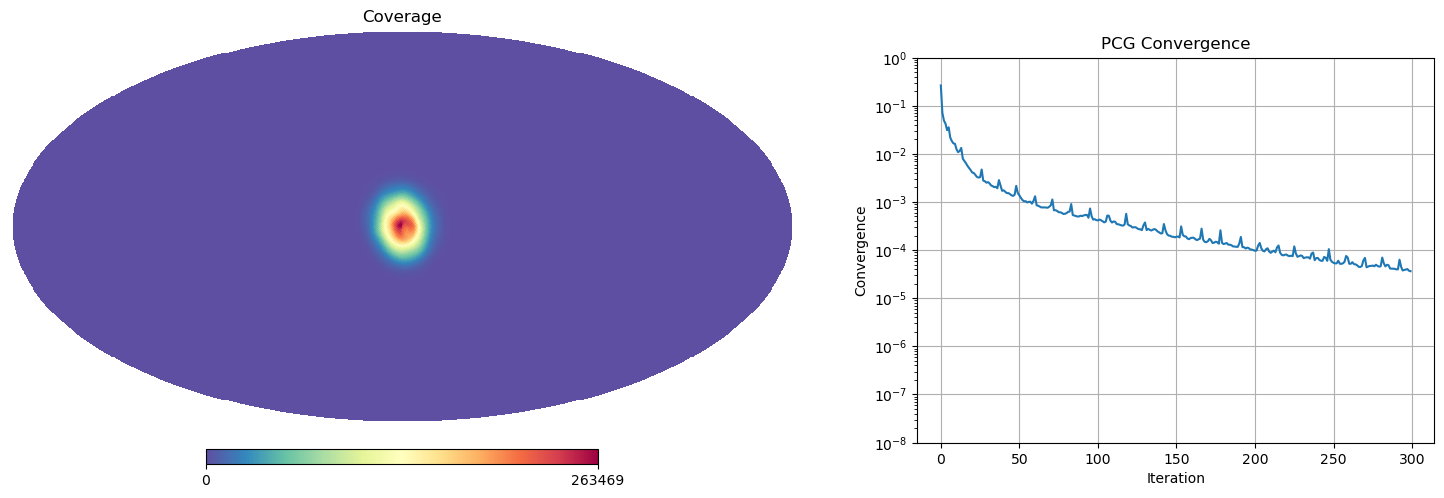

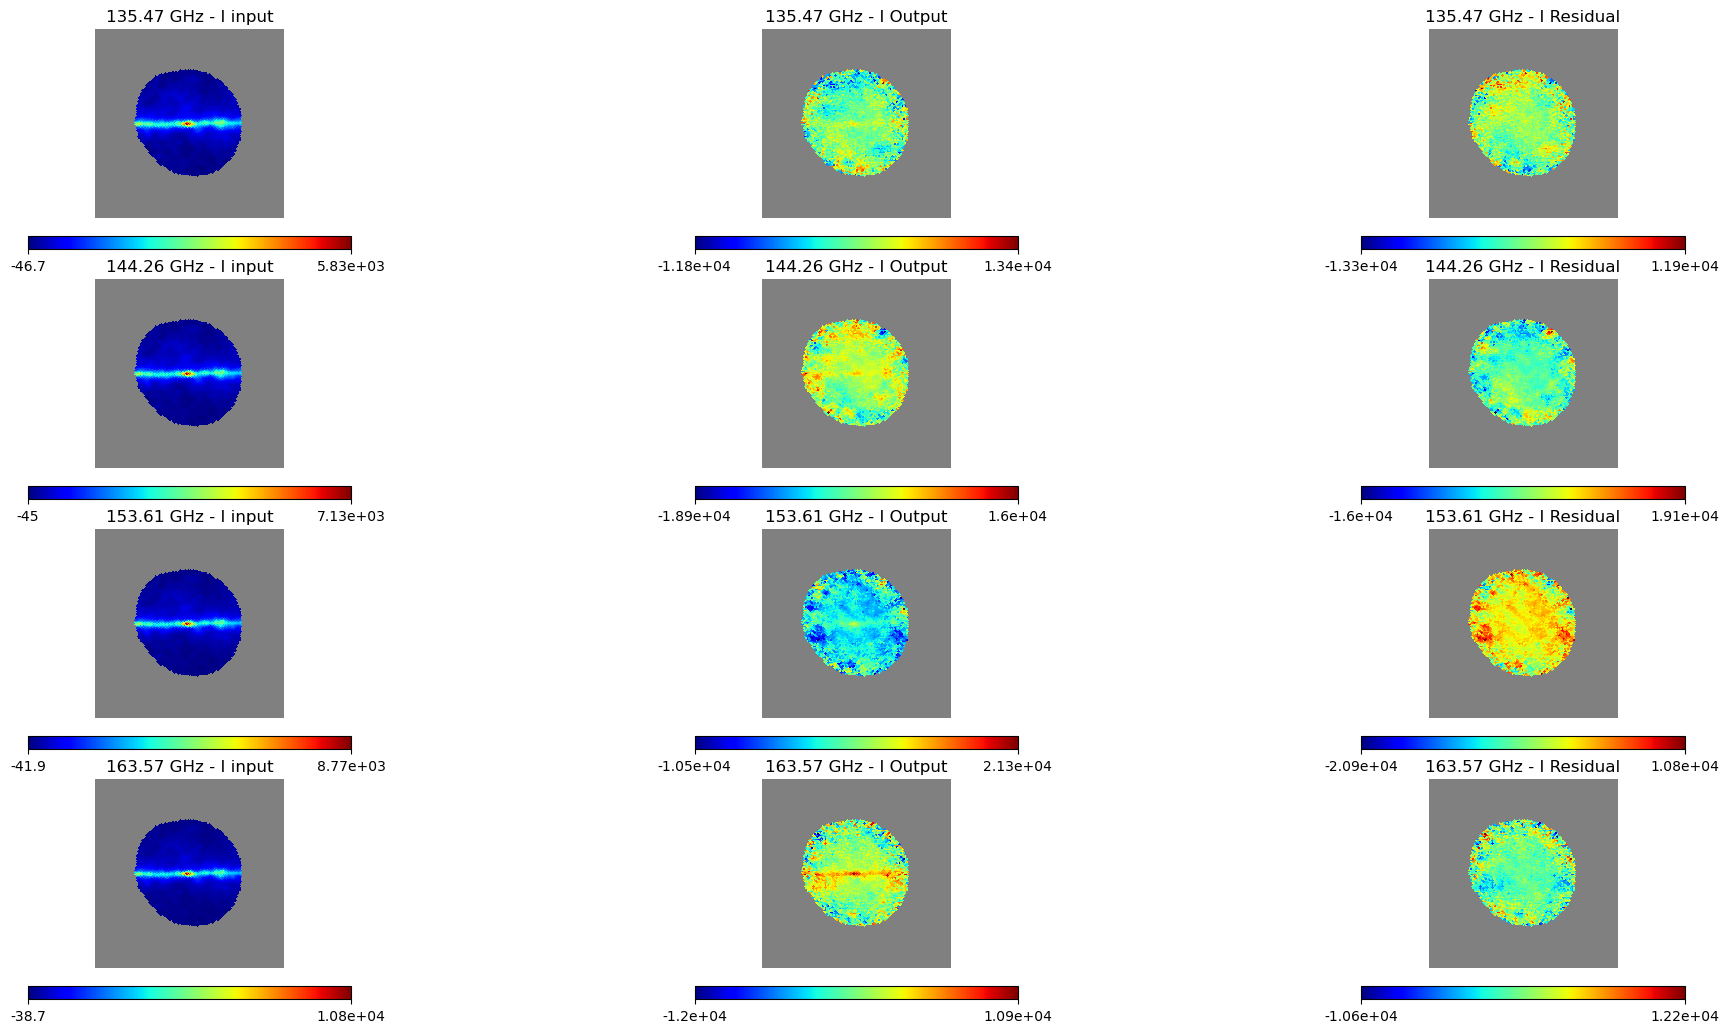

In [25]:
inspect_maps("/media/mattia/Hard Disk/data/test_noise/15days_sp.pkl")

### Coverage comparison

In [4]:
data_rp = pickle.load(open("/media/mattia/Hard Disk/data/test_noise/15days_rp.pkl", "rb"))
coverage_rp = data_rp['coverage']
del data_rp

data_ss = pickle.load(open("/media/mattia/Hard Disk/data/test_noise/15days_ss.pkl", "rb"))
coverage_ss = data_ss['coverage']
del data_ss

data_sp = pickle.load(open("/media/mattia/Hard Disk/data/test_noise/15days_sp.pkl", "rb"))
coverage_sp = data_sp['coverage']
del data_sp

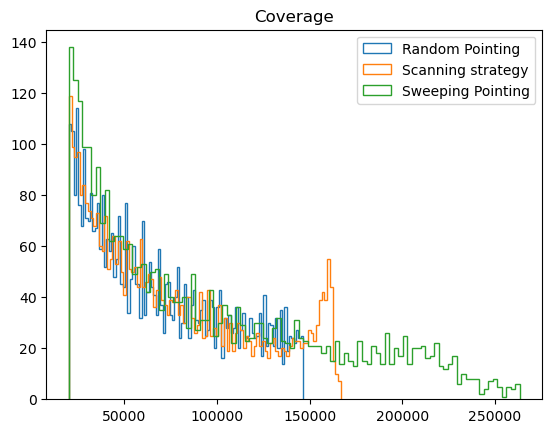

In [15]:
plt.hist(coverage_rp[coverage_rp>20000], bins=100, histtype='step', label='Random Pointing')
plt.hist(coverage_ss[coverage_ss>20000], bins=100, histtype='step', label='Scanning strategy')
plt.hist(coverage_sp[coverage_sp>20000], bins=100, histtype='step', label='Sweeping Pointing')
plt.title('Coverage')
plt.legend()

In [21]:
print('Random pointings:', np.sum(coverage_rp))
print('Scanning strategy:', np.sum(coverage_ss))
print('Sweeping pointings: ', np.sum(coverage_sp))

Random pointings: 324245119.99999994
Scanning strategy: 324245120.0
Sweeping pointings:  321407999.99999994


### Maps comparison

In [22]:
rp = load_maps("/media/mattia/Hard Disk/data/test_noise/15days_rp.pkl")
ss = load_maps("/media/mattia/Hard Disk/data/test_noise/15days_ss.pkl")
sp = load_maps("/media/mattia/Hard Disk/data/test_noise/15days_sp.pkl")

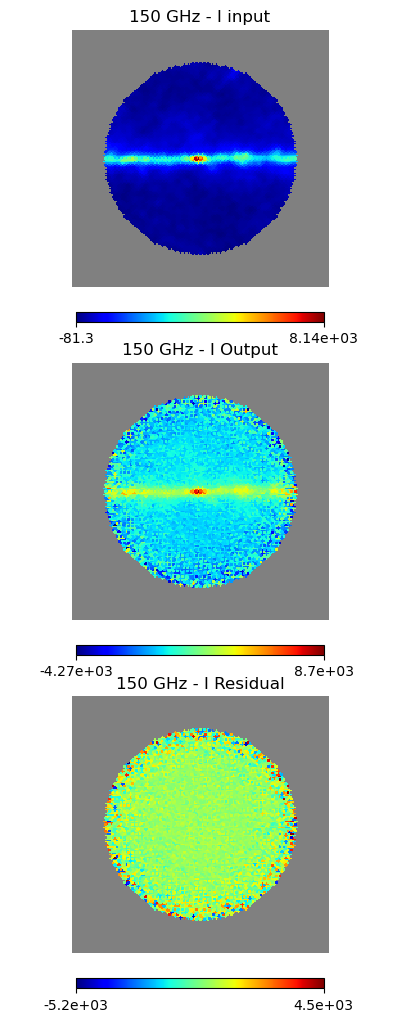

In [33]:
maps_input_mean_rp = np.mean(rp[0], axis=0)
maps_rec_mean_rp = np.mean(rp[1], axis=0)
maps_res_mean_rp = np.mean(rp[2], axis=0)

plt.figure(figsize=(5, 10))
plt.title('Random pointing')
plt.axis('off')
hp.gnomview((maps_input_mean_rp), rot=rp[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(3,1,1))

    
hp.gnomview((maps_rec_mean_rp), rot=rp[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(3,1,2))


hp.gnomview((maps_res_mean_rp), rot=rp[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Residual",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(3,1,3))

In [49]:
brightest_pix_input = np.argmax(maps_input_mean_rp)   # indice del pixel con valore massimo nelle mappe di input
brightest_val = maps_rec_mean_rp[brightest_pix_input]
brightest_val_true = maps_input_mean_rp[brightest_pix_input]

print('coverage pixel più luminoso', coverage_rp[brightest_pix_input])
print('Pixel puù luminoso mappa input', brightest_val_true)
print('Pixel più luminoso mappe ricostruita', brightest_val)
print('SNR', brightest_val_true/(brightest_val-brightest_val_true))

coverage pixel più luminoso 145940.51686217863
Pixel puù luminoso mappa input 8140.484210744878
Pixel più luminoso mappe ricostruita 8703.904210127646
SNR 14.448340881869377


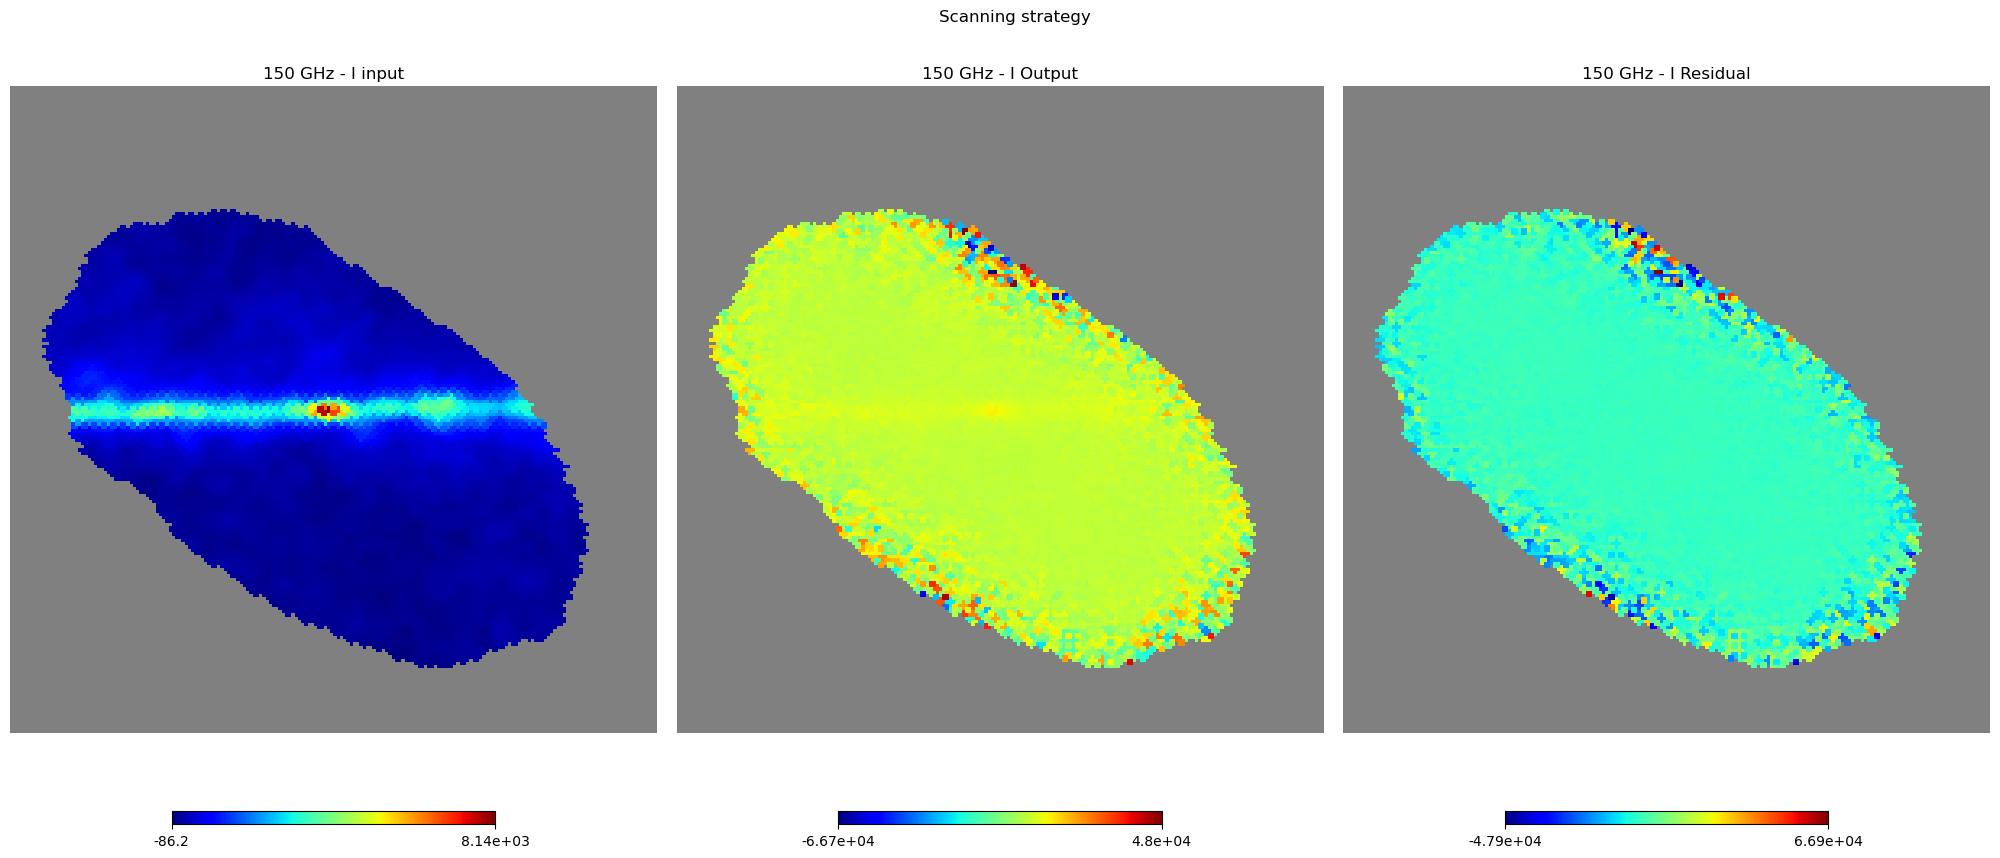

In [ ]:
maps_input_mean_ss = np.mean(ss[0], axis=0)
maps_rec_mean_ss = np.mean(ss[1], axis=0)
maps_res_mean_ss = np.mean(ss[2], axis=0)

plt.figure(figsize=(20, 10))
plt.title('Scanning strategy')
plt.axis('off')
hp.gnomview((maps_input_mean_ss), rot=ss[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(1,3,1))

    
hp.gnomview((maps_rec_mean_ss), rot=ss[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(1,3,2))


hp.gnomview((maps_res_mean_ss), rot=ss[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Residual",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(1,3,3))

In [50]:
brightest_pix_input = np.argmax(maps_input_mean_ss)   # indice del pixel con valore massimo nelle mappe di input
brightest_val = maps_rec_mean_ss[brightest_pix_input]
brightest_val_true = maps_input_mean_ss[brightest_pix_input]

print('coverage pixel più luminoso', coverage_ss[brightest_pix_input])
print('Pixel puù luminoso mappa input', brightest_val_true)
print('Pixel più luminoso mappe ricostruita', brightest_val)
print('SNR', brightest_val_true/(brightest_val-brightest_val_true))

coverage pixel più luminoso 164670.04427201487
Pixel puù luminoso mappa input 8140.484210744878
Pixel più luminoso mappe ricostruita 8549.100544785082
SNR 19.922072449369878


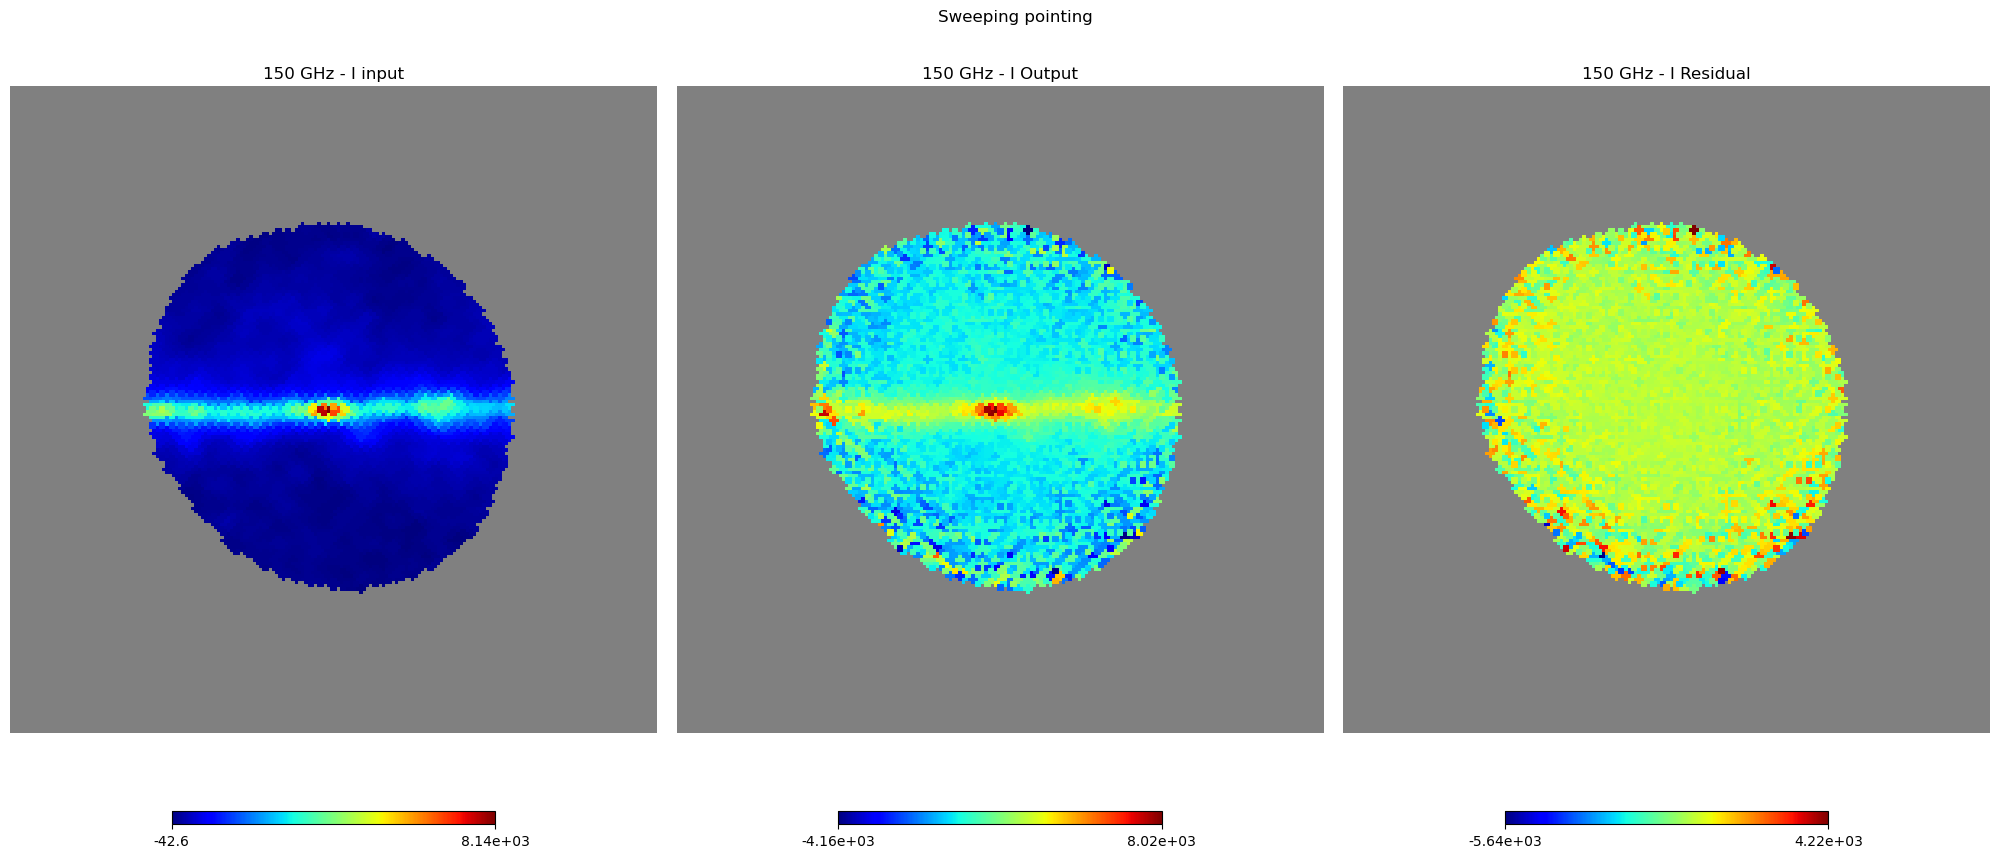

In [48]:
maps_input_mean_sp = np.mean(sp[0], axis=0)
maps_rec_mean_sp = np.mean(sp[1], axis=0)
maps_res_mean_sp = np.mean(sp[2], axis=0)

plt.figure(figsize=(20, 10))
plt.title('Sweeping pointing')
plt.axis('off')
hp.gnomview((maps_input_mean_sp), rot=sp[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(1,3,1))

    
hp.gnomview((maps_rec_mean_sp), rot=sp[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(1,3,2))


hp.gnomview((maps_res_mean_sp), rot=sp[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Residual",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(1,3,3))

In [51]:
brightest_pix_input = np.argmax(maps_input_mean_sp)   # indice del pixel con valore massimo nelle mappe di input
brightest_val = maps_rec_mean_sp[brightest_pix_input]
brightest_val_true = maps_input_mean_sp[brightest_pix_input]

print('coverage pixel più luminoso', coverage_sp[brightest_pix_input])
print('Pixel puù luminoso mappa input', brightest_val_true)
print('Pixel più luminoso mappe ricostruita', brightest_val)
print('SNR', brightest_val_true/(brightest_val-brightest_val_true))

coverage pixel più luminoso 250176.89020894343
Pixel puù luminoso mappa input 8140.484210744878
Pixel più luminoso mappe ricostruita 8020.821075259136
SNR -68.02833786446152


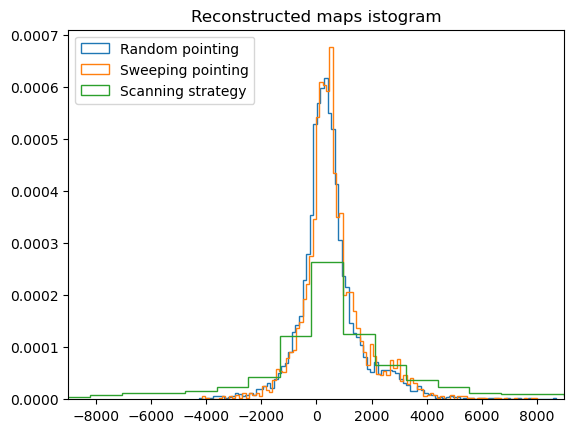

In [55]:
plt.hist(maps_rec_mean_rp[maps_rec_mean_rp>-1e30], bins=100, histtype='step', label='Random pointing', density=True)
plt.hist(maps_rec_mean_sp[maps_rec_mean_sp>-1e30], bins=100, histtype='step', label='Sweeping pointing', density=True)
plt.hist(maps_rec_mean_ss[maps_rec_mean_ss>-1e30], bins=100, histtype='step', label='Scanning strategy', density=True)
#plt.xlim(-30000,30000)
plt.xlim(-9000,9000)
#plt.ylim(0,0.0001)
plt.title('Reconstructed maps istogram')
plt.legend(loc='upper left')

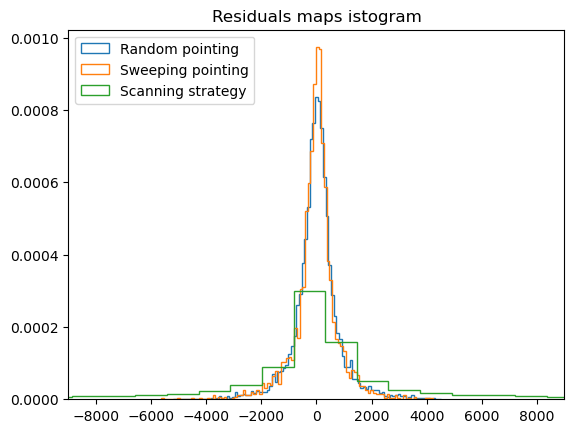

In [57]:
plt.hist(maps_res_mean_rp[maps_res_mean_rp>-1e30], bins=100, histtype='step', label='Random pointing', density=True)
plt.hist(maps_res_mean_sp[maps_res_mean_sp>-1e30], bins=100, histtype='step', label='Sweeping pointing', density=True)
plt.hist(maps_res_mean_ss[maps_res_mean_ss>-1e30], bins=100, histtype='step', label='Scanning strategy', density=True)
#plt.xlim(-30000,30000)
plt.xlim(-9000,9000)
#plt.ylim(0,0.0001)
plt.title('Residuals maps istogram')
plt.legend(loc='upper left')

### TOD comparison

In [3]:
data_rp = pickle.load(open("/media/mattia/Hard Disk/data/test_noise/15days_rp.pkl", "rb"))
tod_rp = data_rp['tod']
del data_rp

data_ss = pickle.load(open("/media/mattia/Hard Disk/data/test_noise/15days_ss.pkl", "rb"))
tod_ss = data_ss['tod']
del data_ss

data_sp = pickle.load(open("/media/mattia/Hard Disk/data/test_noise/15days_sp.pkl", "rb"))
tod_sp = data_sp['tod']
del data_sp

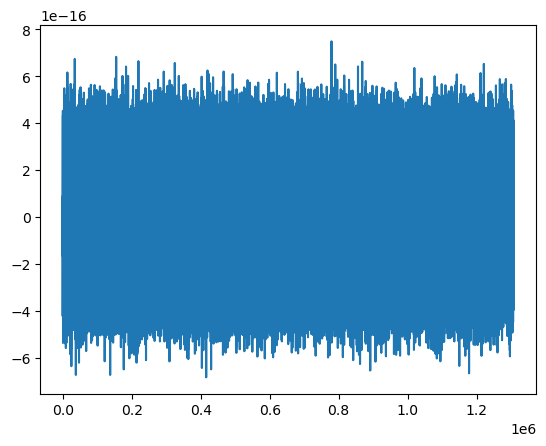

In [ ]:
plt.plot(tod_rp[1307440:1307440*2])

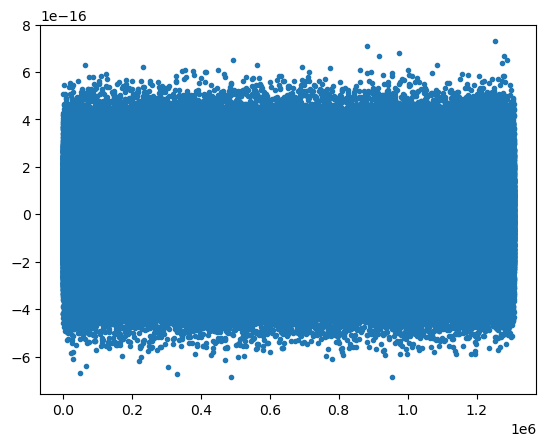

In [7]:
plt.plot(tod_ss[1307440:1307440*2], marker='.', ls='none')

## Giorni di osservazione

In [58]:
pointings = pickle.load(open("/home/mattia/Desktop/pointings_janfeb.pkl", "rb"))
time = pointings.time
diff = time[1:-1]-time[0:-2]

Text(0, 0.5, 'Time difference [hours]')

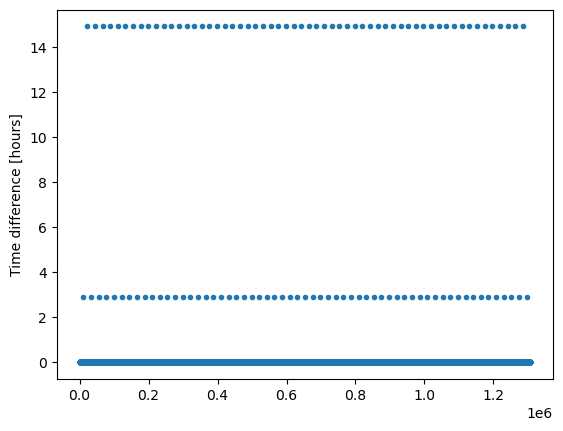

In [60]:
plt.plot(diff/60/60, marker='.', ls='none')
plt.ylabel('Time difference [hours]')

In [64]:
np.unique(diff)

array([5.00000e-01, 5.00000e-01, 5.00000e-01, 5.00000e-01, 5.00000e-01,
       5.00000e-01, 5.00000e-01, 5.00000e-01, 1.00000e+00, 1.00000e+00,
       1.00000e+00, 1.00000e+00, 1.00000e+00, 1.00000e+00, 1.00000e+00,
       1.00000e+00, 1.00000e+00, 1.00000e+00, 1.00000e+00, 1.03575e+04,
       1.03575e+04, 1.03575e+04, 1.03575e+04, 1.03585e+04, 1.03585e+04,
       1.03585e+04, 5.36565e+04, 5.36565e+04, 5.36575e+04, 5.36575e+04,
       5.36575e+04, 5.36575e+04])

Ci sono salti temporali di 3 ore oppure di 15 ore 

In [73]:
three_hours = np.unique(diff)[17:23]
fifteen_hours = np.unique(diff)[23:]

In [74]:
from astropy.time import Time, TimeDelta

t0 = Time("2026-01-01 00:00:00", scale="utc")
dt = TimeDelta(time, format="sec") 
t = t0 + dt

In [67]:
idx = np.empty(0)
for i in three_hours:
    idx = np.concatenate([idx, np.where(diff==i)[0]])
idx = np.sort(idx)
idx

array([  11079.,   26302.,   26384., ..., 1163399., 1185559., 1296359.])

In [71]:
i = 11079
t[i:i+2]

<Time object: scale='utc' format='iso' value=['2026-01-01 14:01:43.350' '2026-01-01 16:54:20.850']>

In [75]:
idx = np.empty(0)
for i in fifteen_hours:
    idx = np.concatenate([idx, np.where(diff==i)[0]])
idx = np.sort(idx)
idx

array([  22159.,   44319.,   66479.,   88639.,   99719.,  110799.,
        121879.,  132959.,  144039.,  155119.,  166199.,  177279.,
        199439.,  221599.,  243759.,  265919.,  288079.,  299159.,
        310239.,  321319.,  332399.,  343479.,  354559.,  365639.,
        376719.,  398879.,  421039.,  443199.,  465359.,  487519.,
        498599.,  509679.,  520759.,  531839.,  542919.,  553999.,
        576159.,  598319.,  620479.,  642639.,  664799.,  675879.,
        686959.,  698039.,  709119.,  720199.,  731279.,  742359.,
        753439.,  775599.,  797759.,  819919.,  842079.,  853159.,
        864239.,  875319.,  886399.,  897479.,  908559.,  919639.,
        930719.,  952879.,  975039.,  997199., 1019359., 1030439.,
       1041519., 1052599., 1063679., 1074759., 1085839., 1096919.,
       1107999., 1130159., 1152319., 1174479., 1196639., 1207719.,
       1218799., 1229879., 1240959., 1252039., 1263119., 1274199.,
       1285279.])

In [76]:
i = 22159
t[i:i+2]

<Time object: scale='utc' format='iso' value=['2026-01-01 19:58:55.350' '2026-01-02 10:53:12.850']>

# On hwp and pitch angle influence

L'idea ora è quella di capire perchè con la scanning strategy il rumore è più alto rispetto allo sweeping pointing che più o meno fa la stessa cosa. Le idee sono tre:
- influenza del pitch angle
- influenza del hwp angle
- influenza della scansione del cielo non continua

Qui analizzo i primi due punti confrontando le simulazioni con scanning strategy e sweeping pointing per pochi giorni (4 giorni per la scanning strategy corrispondenti a 24 ore di osservazione effettiva) per velocizzare le simulazioni

### Scanning strategy

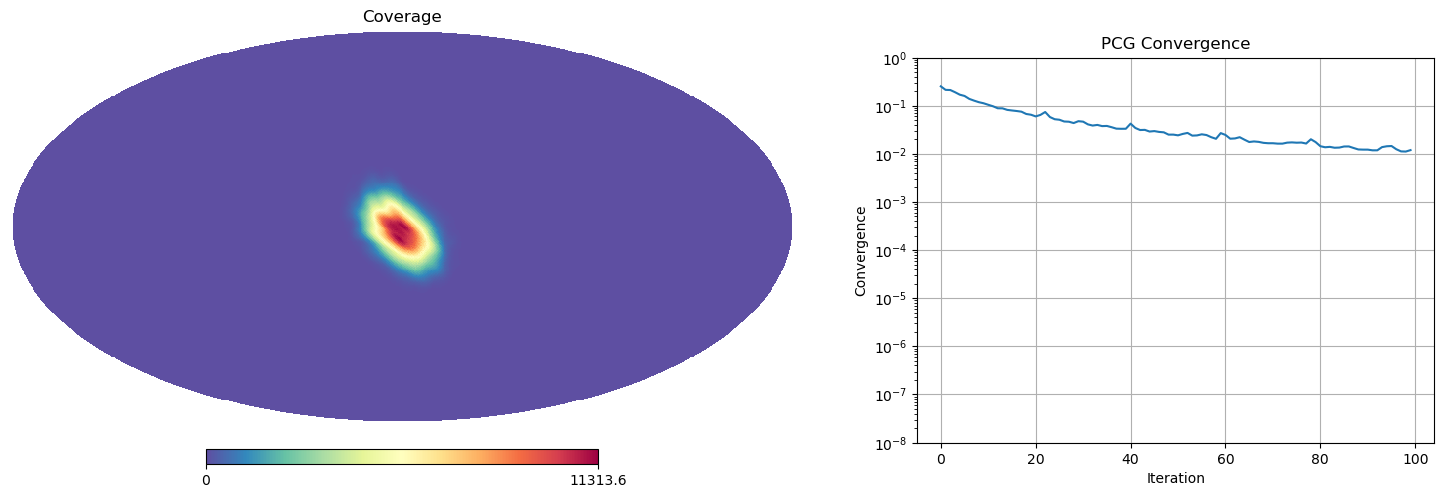

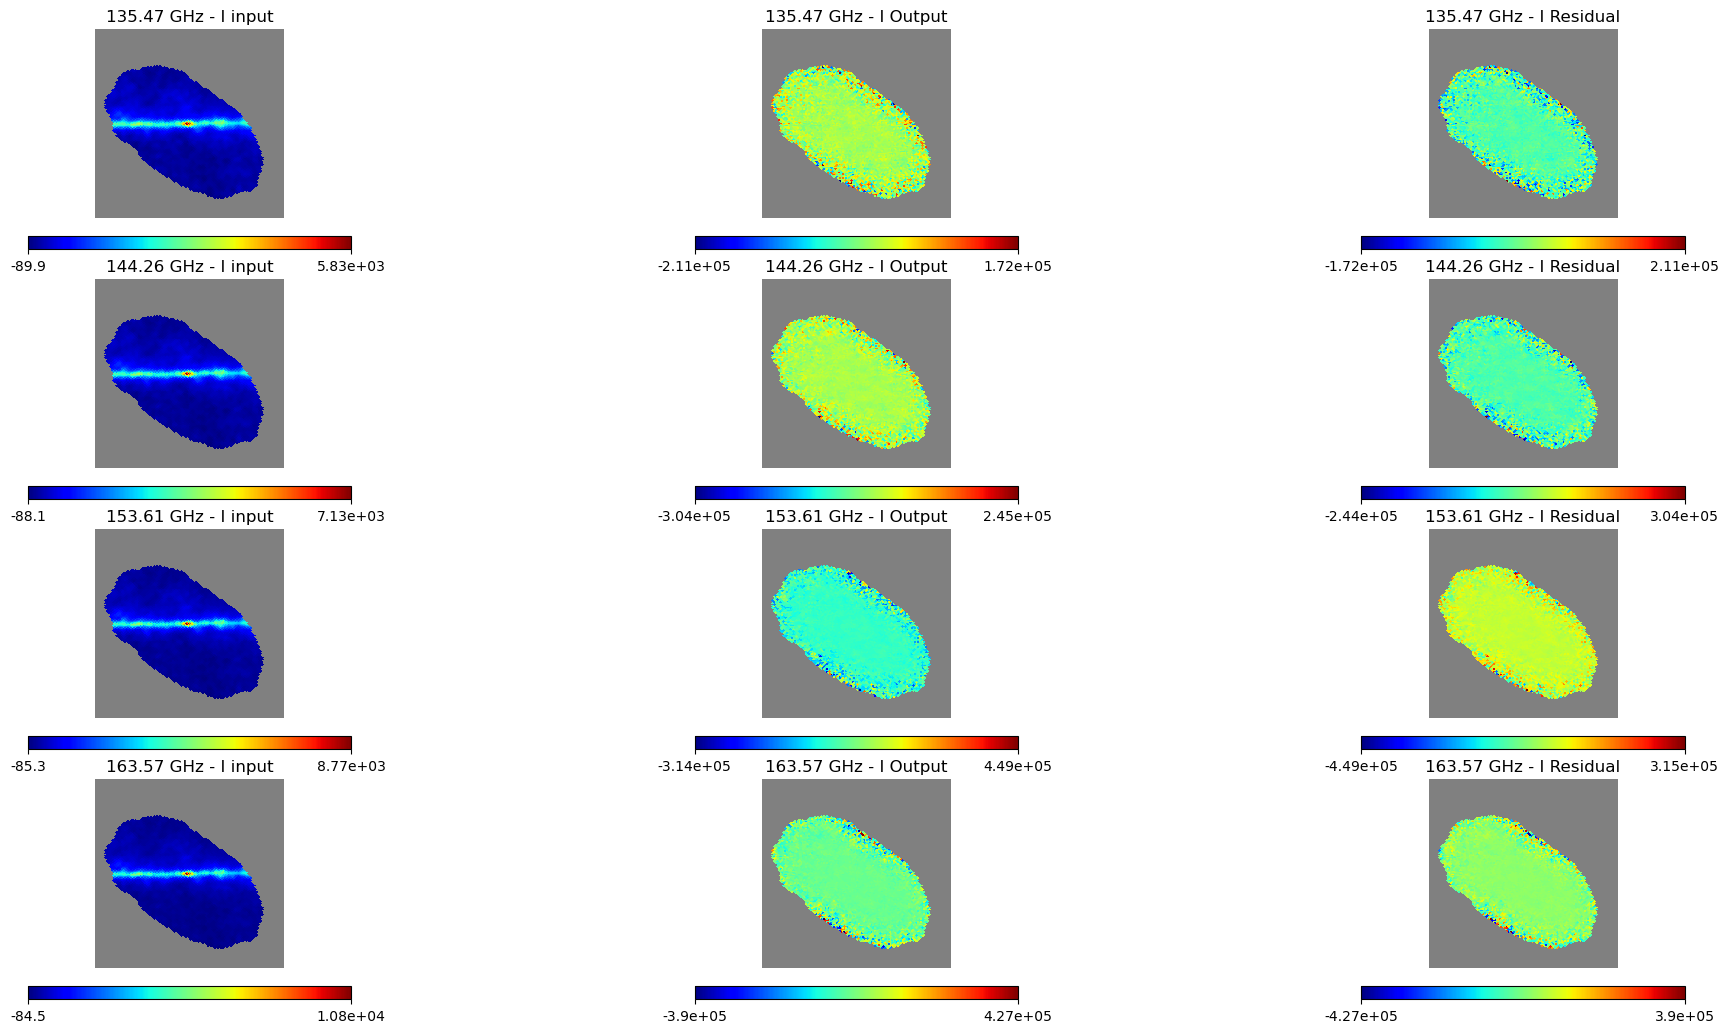

In [9]:
inspect_maps("/media/mattia/Hard Disk/data/sp_vs_ss/ss.pkl")

In [10]:
data = pickle.load(open("/media/mattia/Hard Disk/data/sp_vs_ss/ss.pkl", "rb"))
coverage = data['coverage']
del data

In [5]:
np.sum(coverage)/248/60/60

24.622222222222213

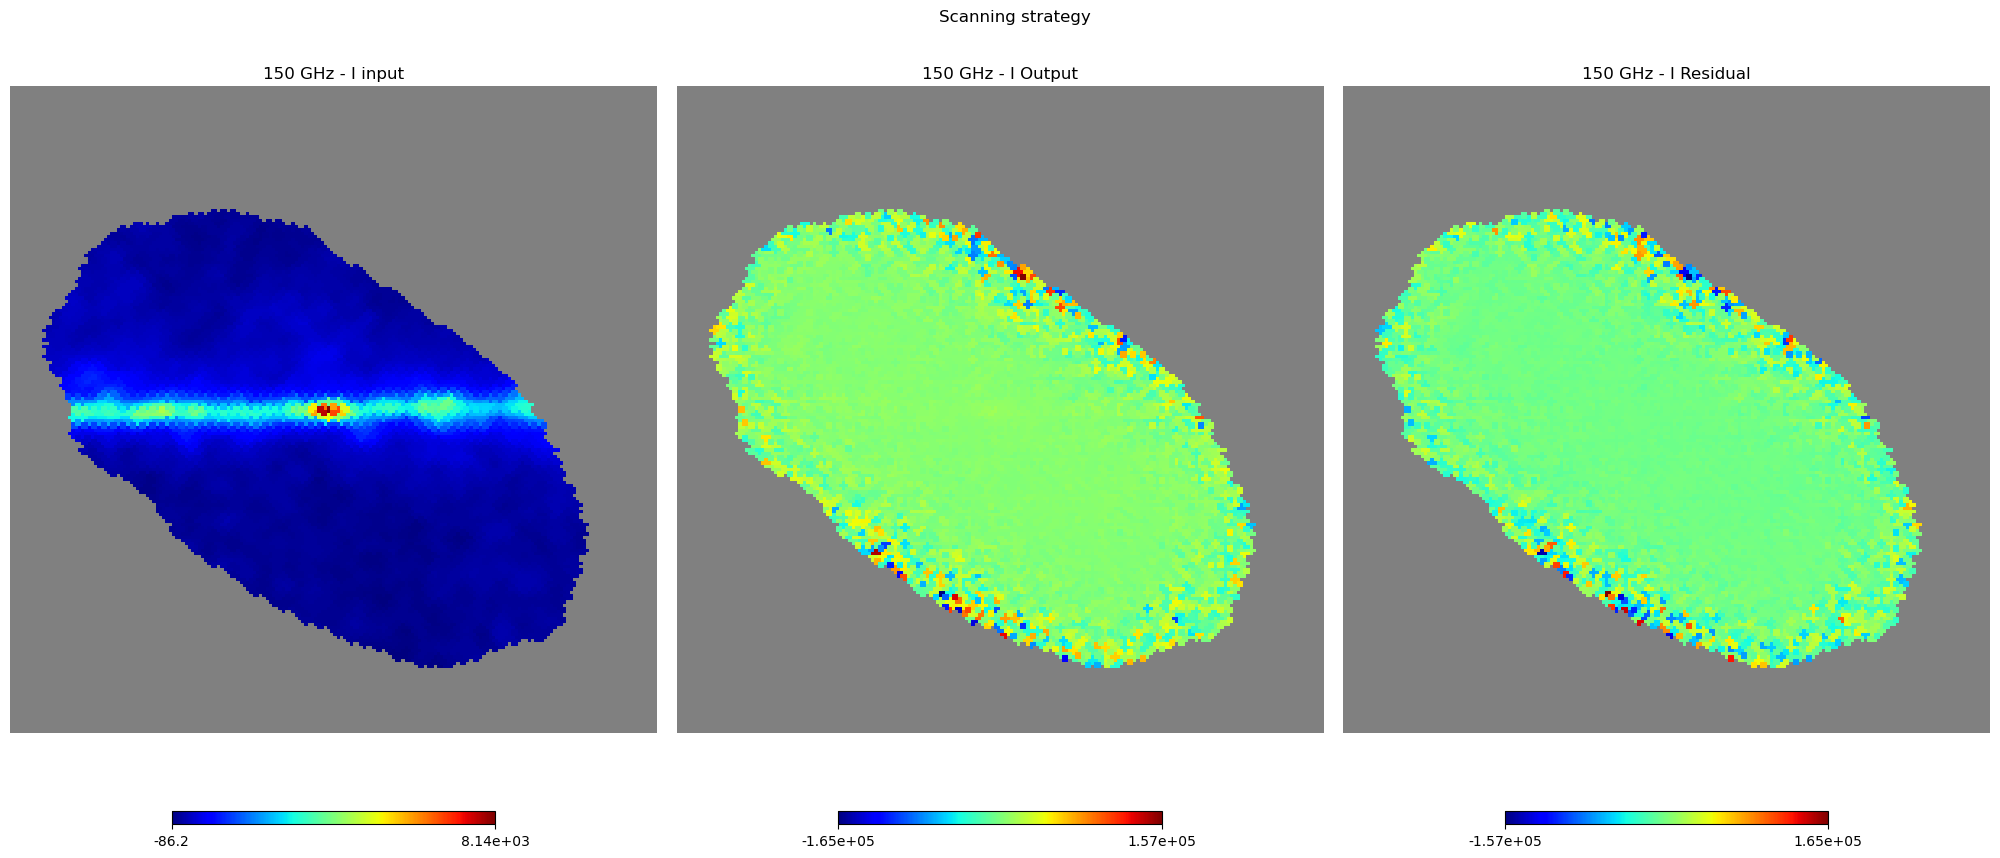

In [16]:
ss = load_maps("/media/mattia/Hard Disk/data/sp_vs_ss/ss.pkl")

maps_input_mean_ss = np.mean(ss[0], axis=0)
maps_rec_mean_ss = np.mean(ss[1], axis=0)
maps_res_mean_ss = np.mean(ss[2], axis=0)

plt.figure(figsize=(20, 10))
plt.title('Scanning strategy')
plt.axis('off')
hp.gnomview((maps_input_mean_ss), rot=ss[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(1,3,1))

    
hp.gnomview((maps_rec_mean_ss), rot=ss[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(1,3,2))


hp.gnomview((maps_res_mean_ss), rot=ss[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Residual",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(1,3,3))

In [12]:
brightest_pix_input = np.argmax(maps_input_mean_ss)   # indice del pixel con valore massimo nelle mappe di input
brightest_val = maps_rec_mean_ss[brightest_pix_input]
brightest_val_true = maps_input_mean_ss[brightest_pix_input]

#print('coverage pixel più luminoso', coverage_rp[brightest_pix_input])
print('Pixel più luminoso mappa input', brightest_val_true)
print('Pixel più luminoso mappe ricostruita', brightest_val)
print('SNR', brightest_val_true/(brightest_val-brightest_val_true))

Pixel più luminoso mappa input 8140.484210744878
Pixel più luminoso mappe ricostruita 10144.34549275884
SNR 4.0623990711389775


### Sweeping pointing

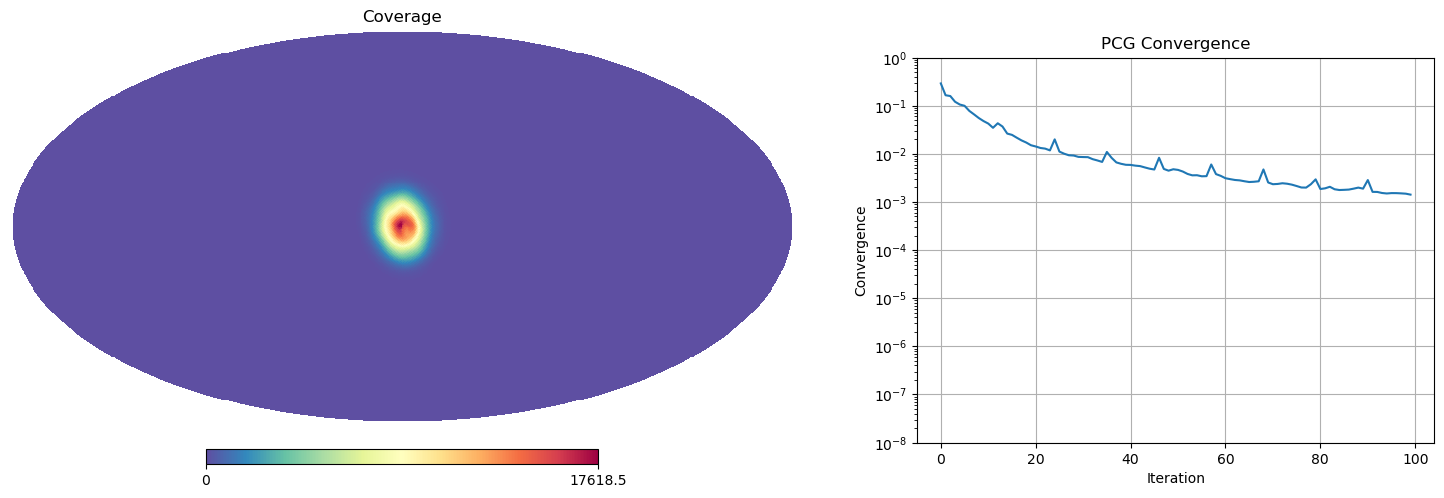

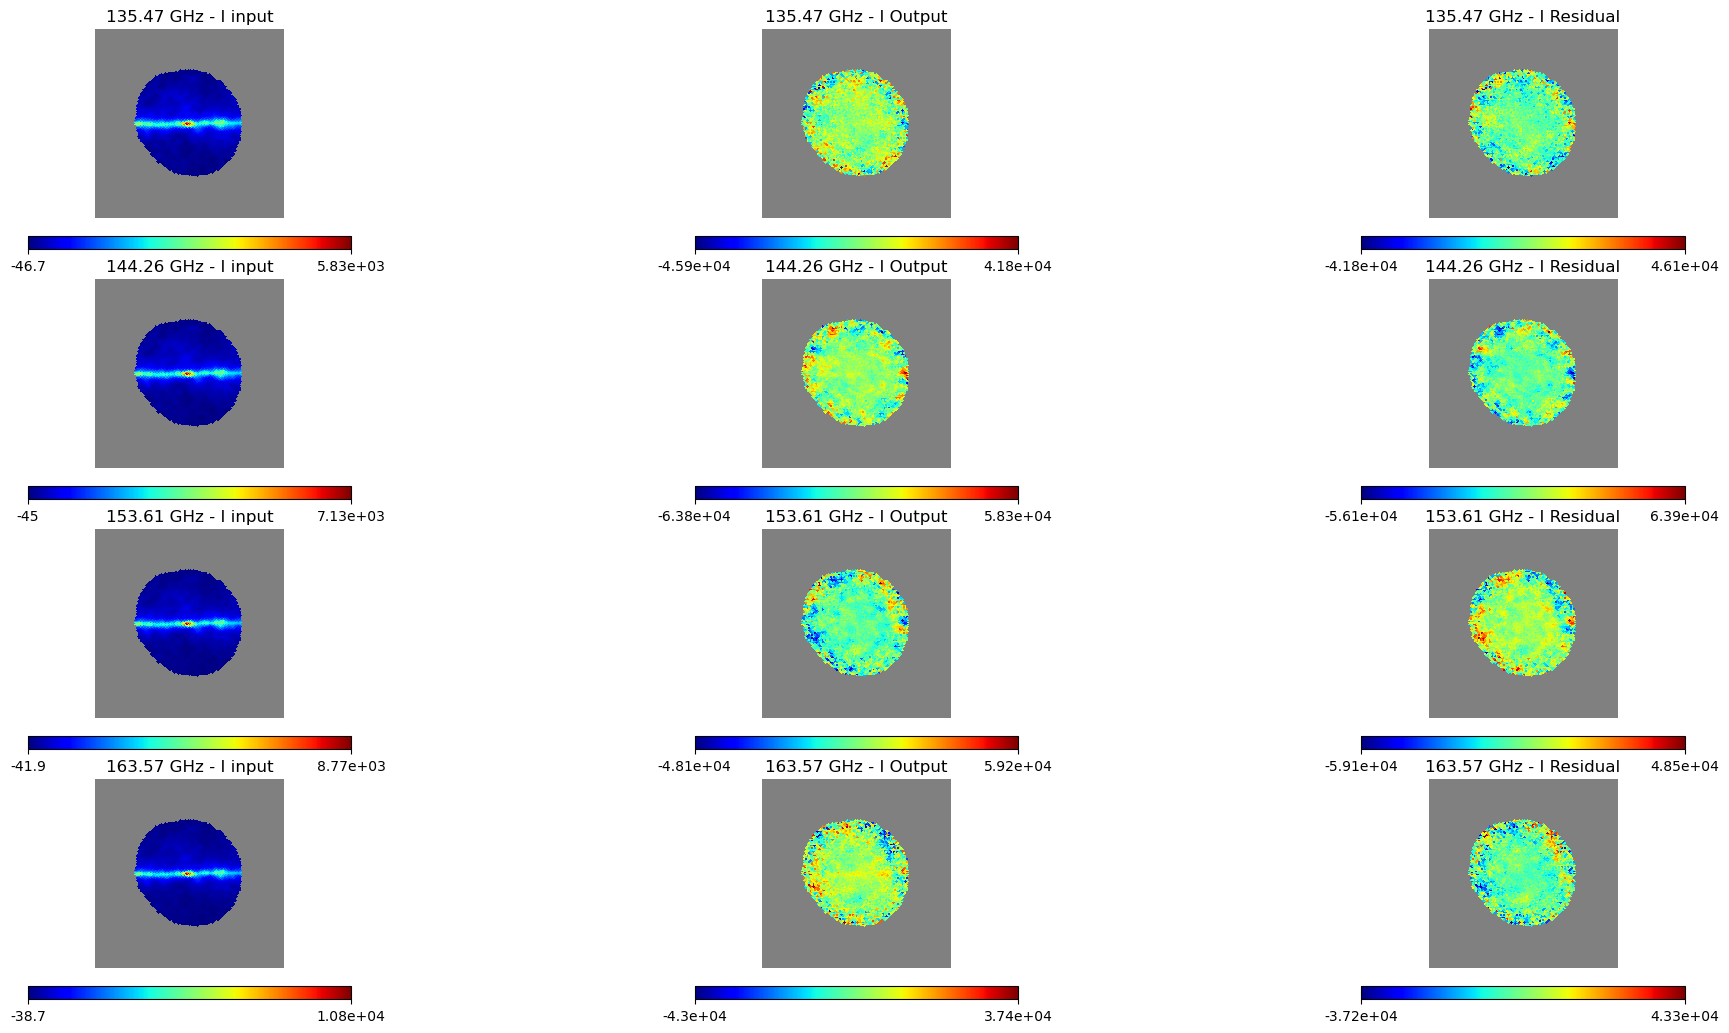

In [39]:
inspect_maps("/media/mattia/Hard Disk/data/sp_vs_ss/sp.pkl")

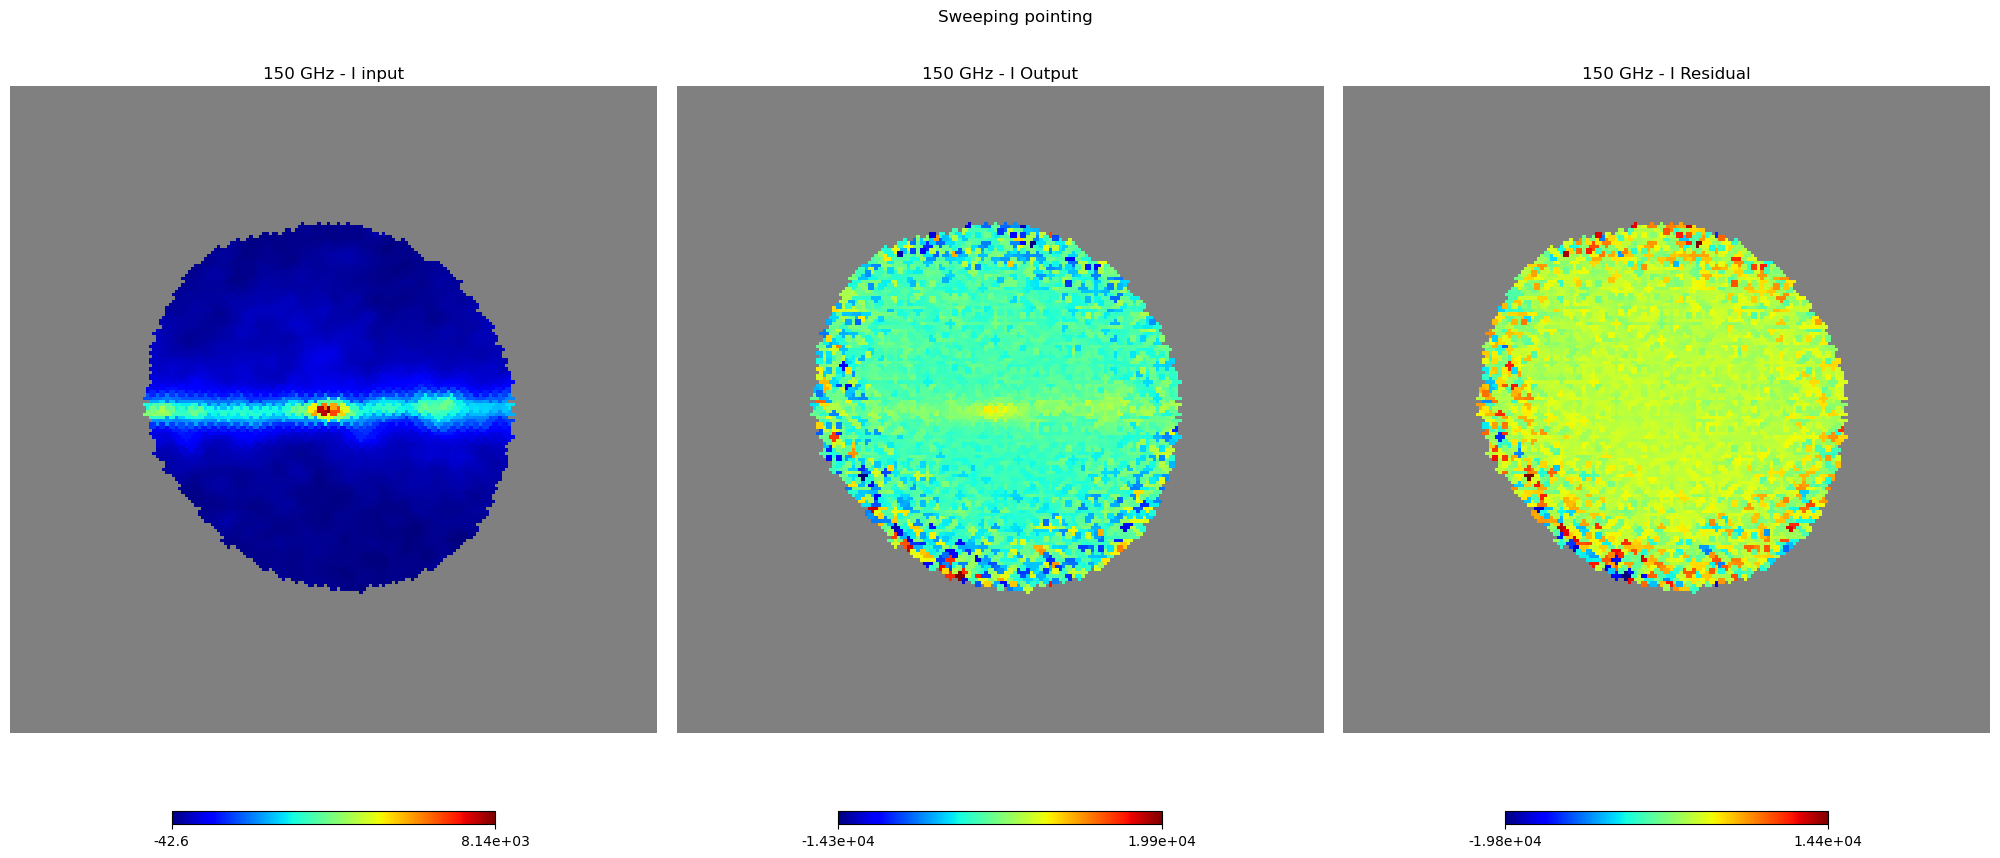

In [42]:
sp = load_maps("/media/mattia/Hard Disk/data/sp_vs_ss/sp.pkl")

maps_input_mean_sp = np.mean(sp[0], axis=0)
maps_rec_mean_sp = np.mean(sp[1], axis=0)
maps_res_mean_sp = np.mean(sp[2], axis=0)

plt.figure(figsize=(20, 10))
plt.title('Sweeping pointing')
plt.axis('off')
hp.gnomview((maps_input_mean_sp), rot=sp[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(1,3,1))

    
hp.gnomview((maps_rec_mean_sp), rot=sp[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(1,3,2))


hp.gnomview((maps_res_mean_sp), rot=sp[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Residual",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(1,3,3))

In [15]:
brightest_pix_input = np.argmax(maps_input_mean_sp)   # indice del pixel con valore massimo nelle mappe di input
brightest_val = maps_rec_mean_sp[brightest_pix_input]
brightest_val_true = maps_input_mean_sp[brightest_pix_input]

#print('coverage pixel più luminoso', coverage_rp[brightest_pix_input])
print('Pixel più luminoso mappa input', brightest_val_true)
print('Pixel più luminoso mappe ricostruita', brightest_val)
print('SNR', brightest_val_true/(brightest_val-brightest_val_true))

Pixel più luminoso mappa input 8140.484210744878
Pixel più luminoso mappe ricostruita 8349.099625958504
SNR 39.021489387104204


### Sweeping pointing (pitch and hwp fixed)

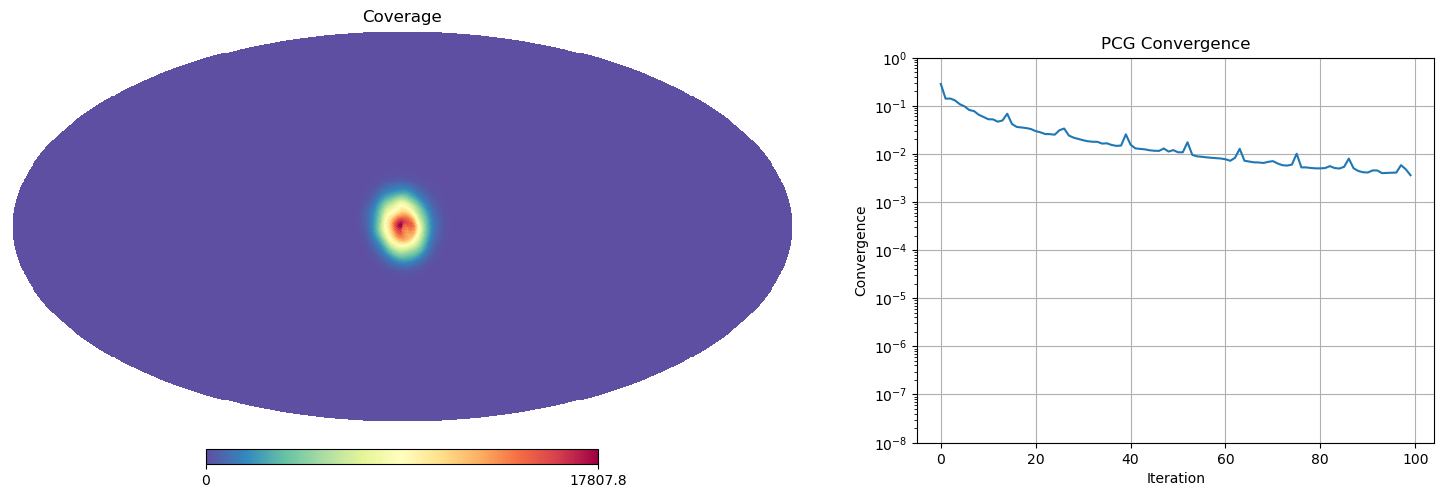

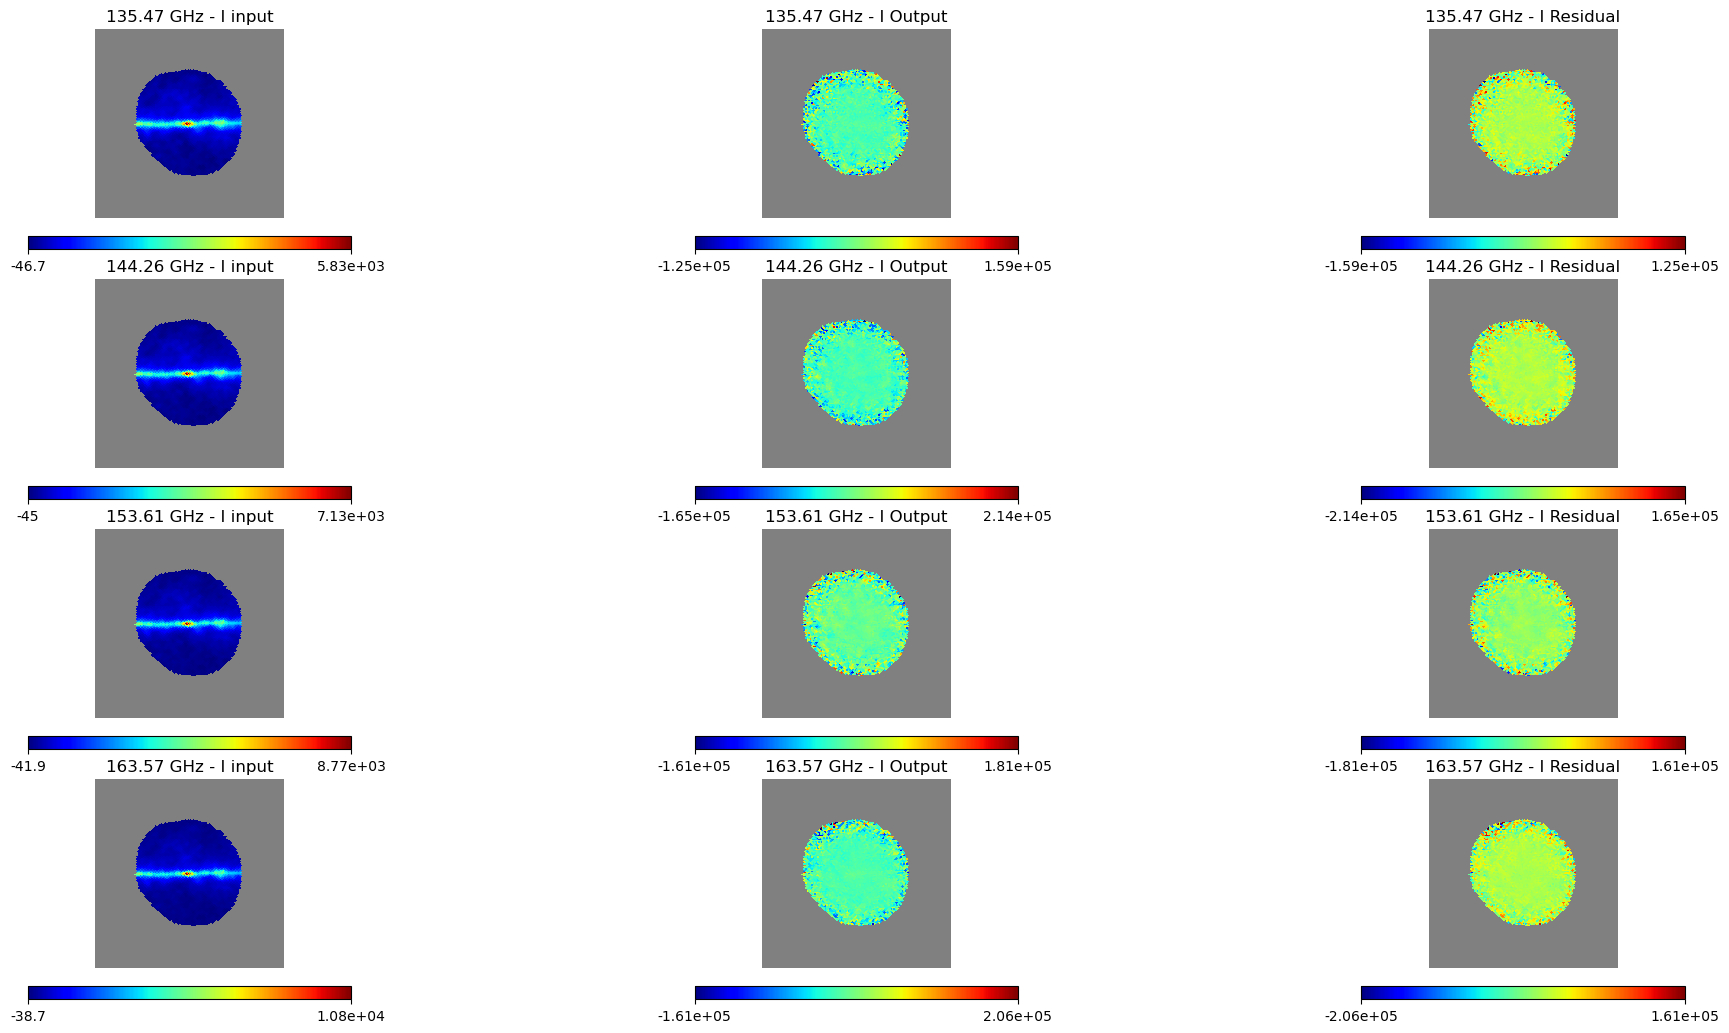

In [16]:
inspect_maps("/media/mattia/Hard Disk/data/sp_vs_ss/sp_pitch_hwp_fixed.pkl")

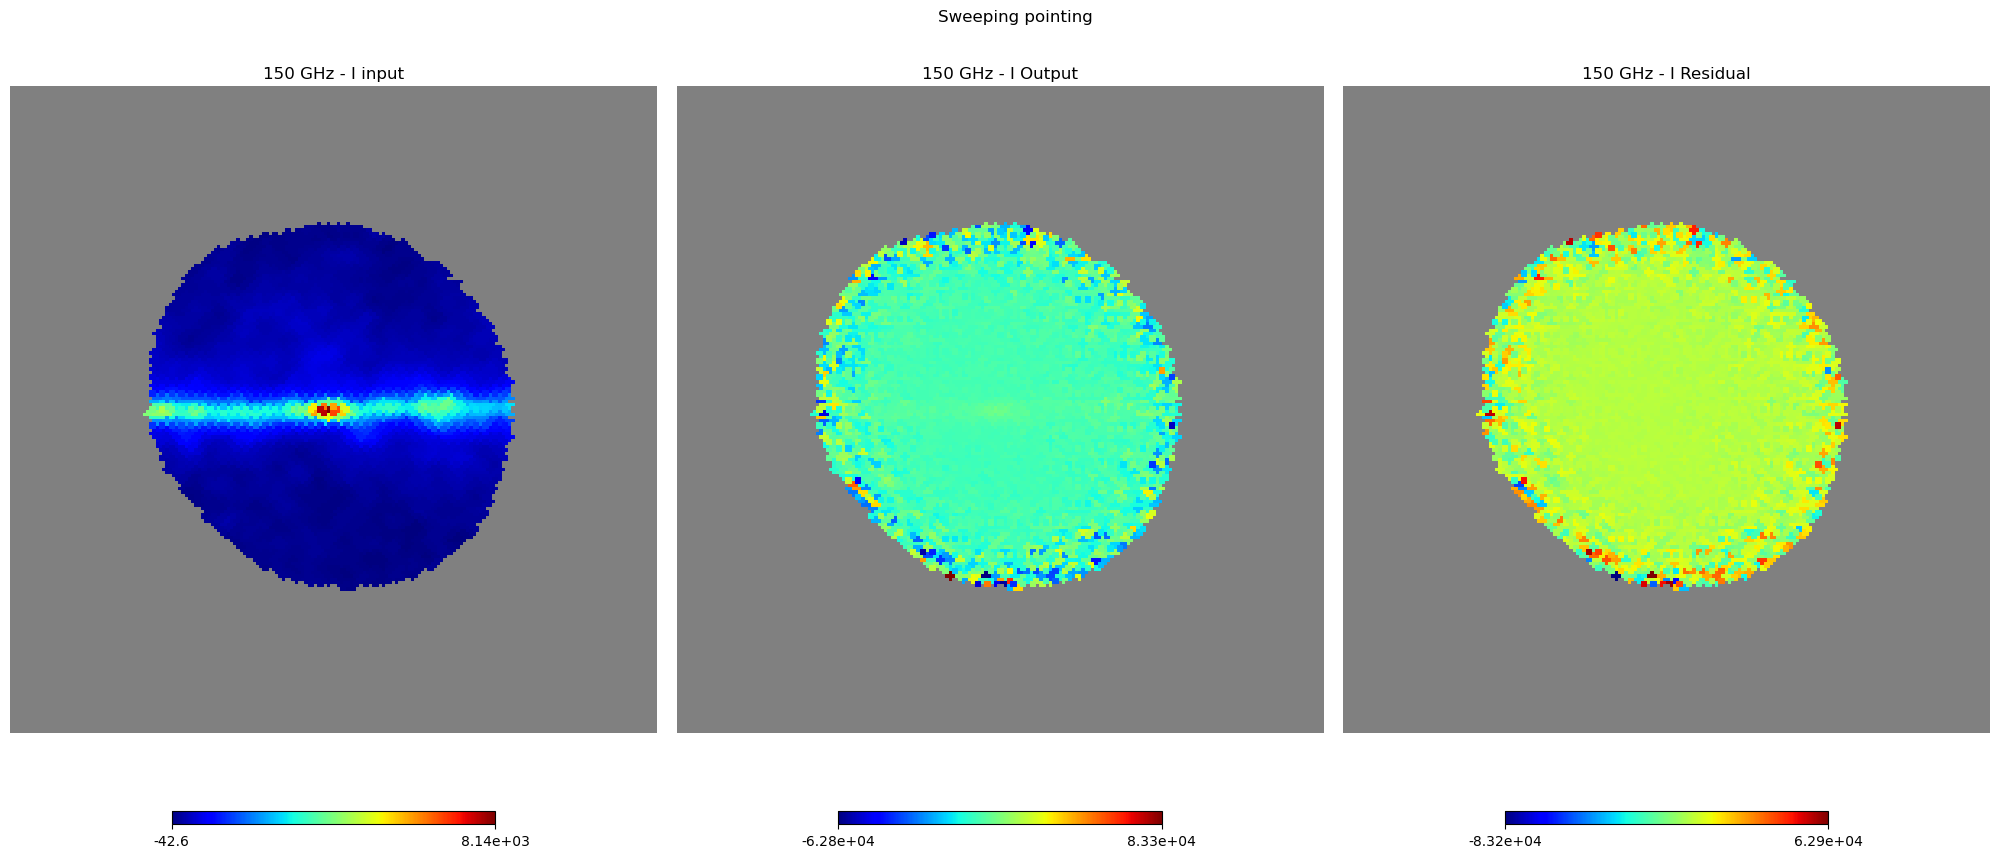

In [18]:
sp2 = load_maps("/media/mattia/Hard Disk/data/sp_vs_ss/sp_pitch_hwp_fixed.pkl")

maps_input_mean_sp2 = np.mean(sp2[0], axis=0)
maps_rec_mean_sp2 = np.mean(sp2[1], axis=0)
maps_res_mean_sp2 = np.mean(sp2[2], axis=0)

plt.figure(figsize=(20, 10))
plt.title('Sweeping pointing')
plt.axis('off')
hp.gnomview((maps_input_mean_sp2), rot=sp2[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(1,3,1))

    
hp.gnomview((maps_rec_mean_sp2), rot=sp2[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(1,3,2))


hp.gnomview((maps_res_mean_sp2), rot=sp2[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Residual",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(1,3,3))

In [18]:
brightest_pix_input = np.argmax(maps_input_mean_sp2)   # indice del pixel con valore massimo nelle mappe di input
brightest_val = maps_rec_mean_sp2[brightest_pix_input]
brightest_val_true = maps_input_mean_sp2[brightest_pix_input]

#print('coverage pixel più luminoso', coverage_rp[brightest_pix_input])
print('Pixel più luminoso mappa input', brightest_val_true)
print('Pixel più luminoso mappe ricostruita', brightest_val)
print('SNR', brightest_val_true/(brightest_val-brightest_val_true))

Pixel più luminoso mappa input 8140.484210744878
Pixel più luminoso mappe ricostruita 8649.555542999315
SNR 15.990851762747097


### Sweeping pointing (pitch fixed)

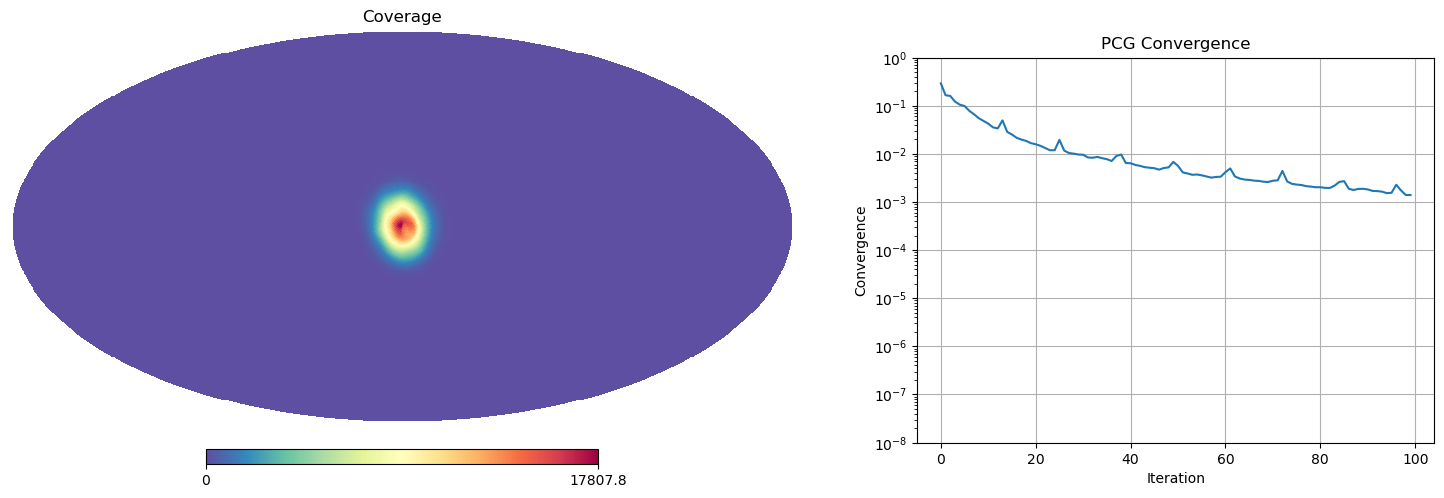

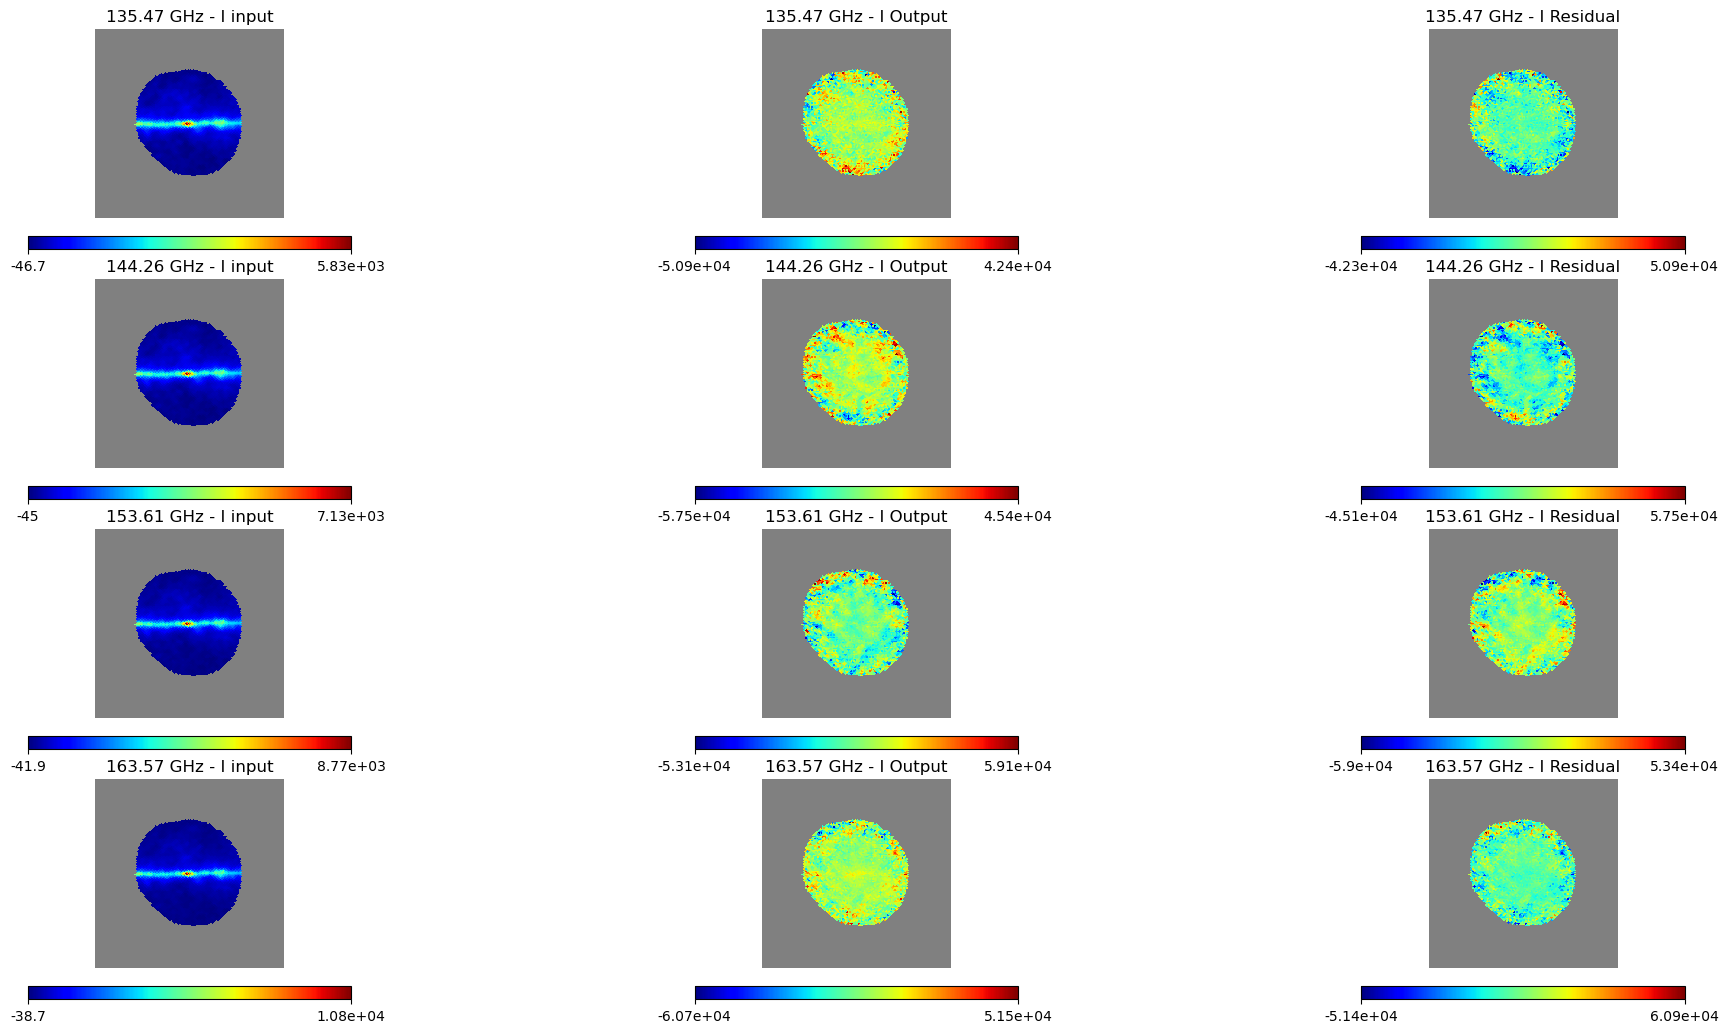

In [19]:
inspect_maps("/media/mattia/Hard Disk/data/sp_vs_ss/sp_pitch_fixed.pkl")

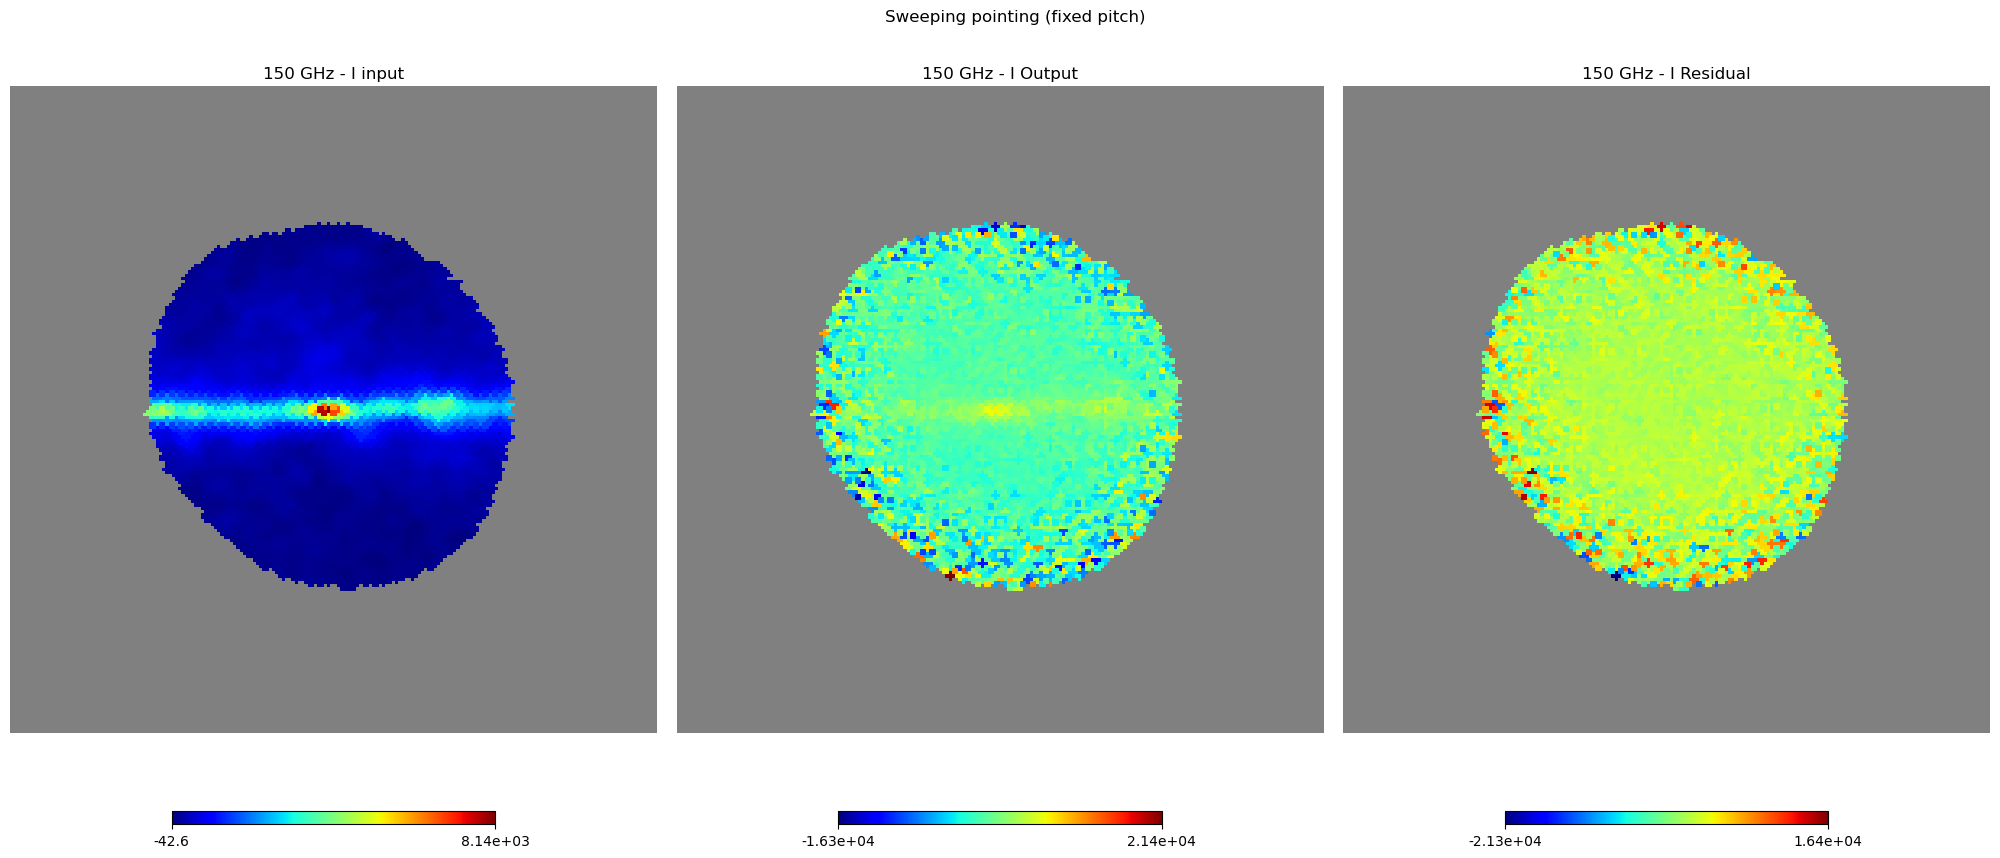

In [19]:
sp3 = load_maps("/media/mattia/Hard Disk/data/sp_vs_ss/sp_pitch_fixed.pkl")

maps_input_mean_sp3 = np.mean(sp3[0], axis=0)
maps_rec_mean_sp3 = np.mean(sp3[1], axis=0)
maps_res_mean_sp3 = np.mean(sp3[2], axis=0)

plt.figure(figsize=(20, 10))
plt.title('Sweeping pointing (fixed pitch)')
plt.axis('off')
hp.gnomview((maps_input_mean_sp3), rot=sp3[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(1,3,1))

    
hp.gnomview((maps_rec_mean_sp3), rot=sp3[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(1,3,2))


hp.gnomview((maps_res_mean_sp3), rot=sp3[4],
                        reso=15,
                        notext=True,
                        title=f"150 GHz - I Residual",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(1,3,3))

In [21]:
brightest_pix_input = np.argmax(maps_input_mean_sp3)   # indice del pixel con valore massimo nelle mappe di input
brightest_val = maps_rec_mean_sp3[brightest_pix_input]
brightest_val_true = maps_input_mean_sp3[brightest_pix_input]

#print('coverage pixel più luminoso', coverage_rp[brightest_pix_input])
print('Pixel più luminoso mappa input', brightest_val_true)
print('Pixel più luminoso mappe ricostruita', brightest_val)
print('SNR', brightest_val_true/(brightest_val-brightest_val_true))

Pixel più luminoso mappa input 8140.484210744878
Pixel più luminoso mappe ricostruita 8416.069828647094
SNR 29.538857189685732


### Scanning strategy with HWP rotation

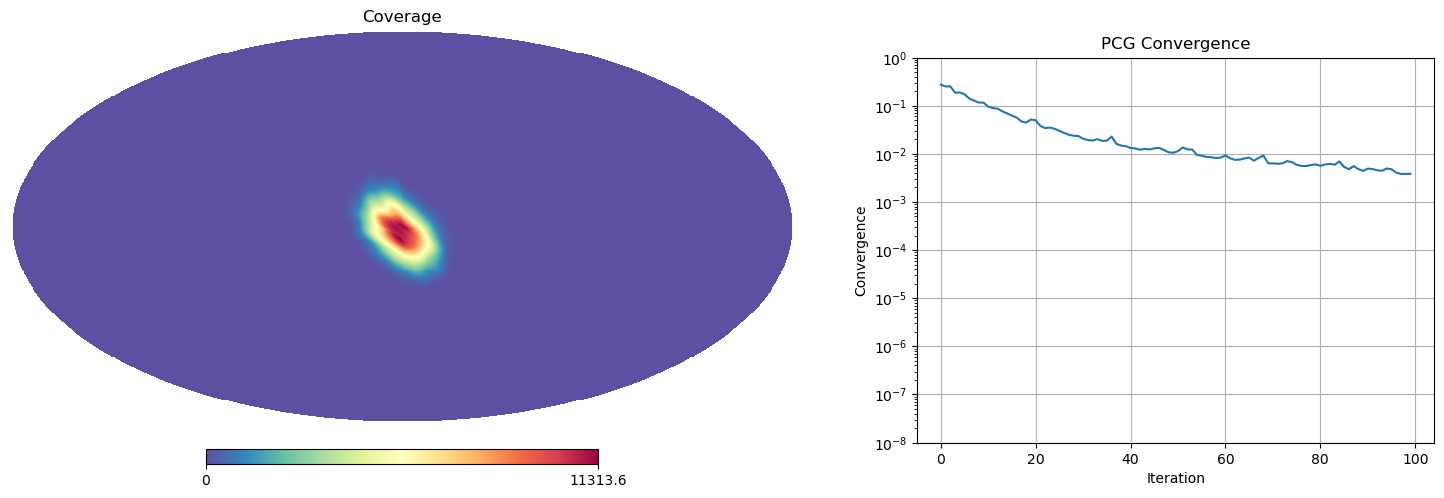

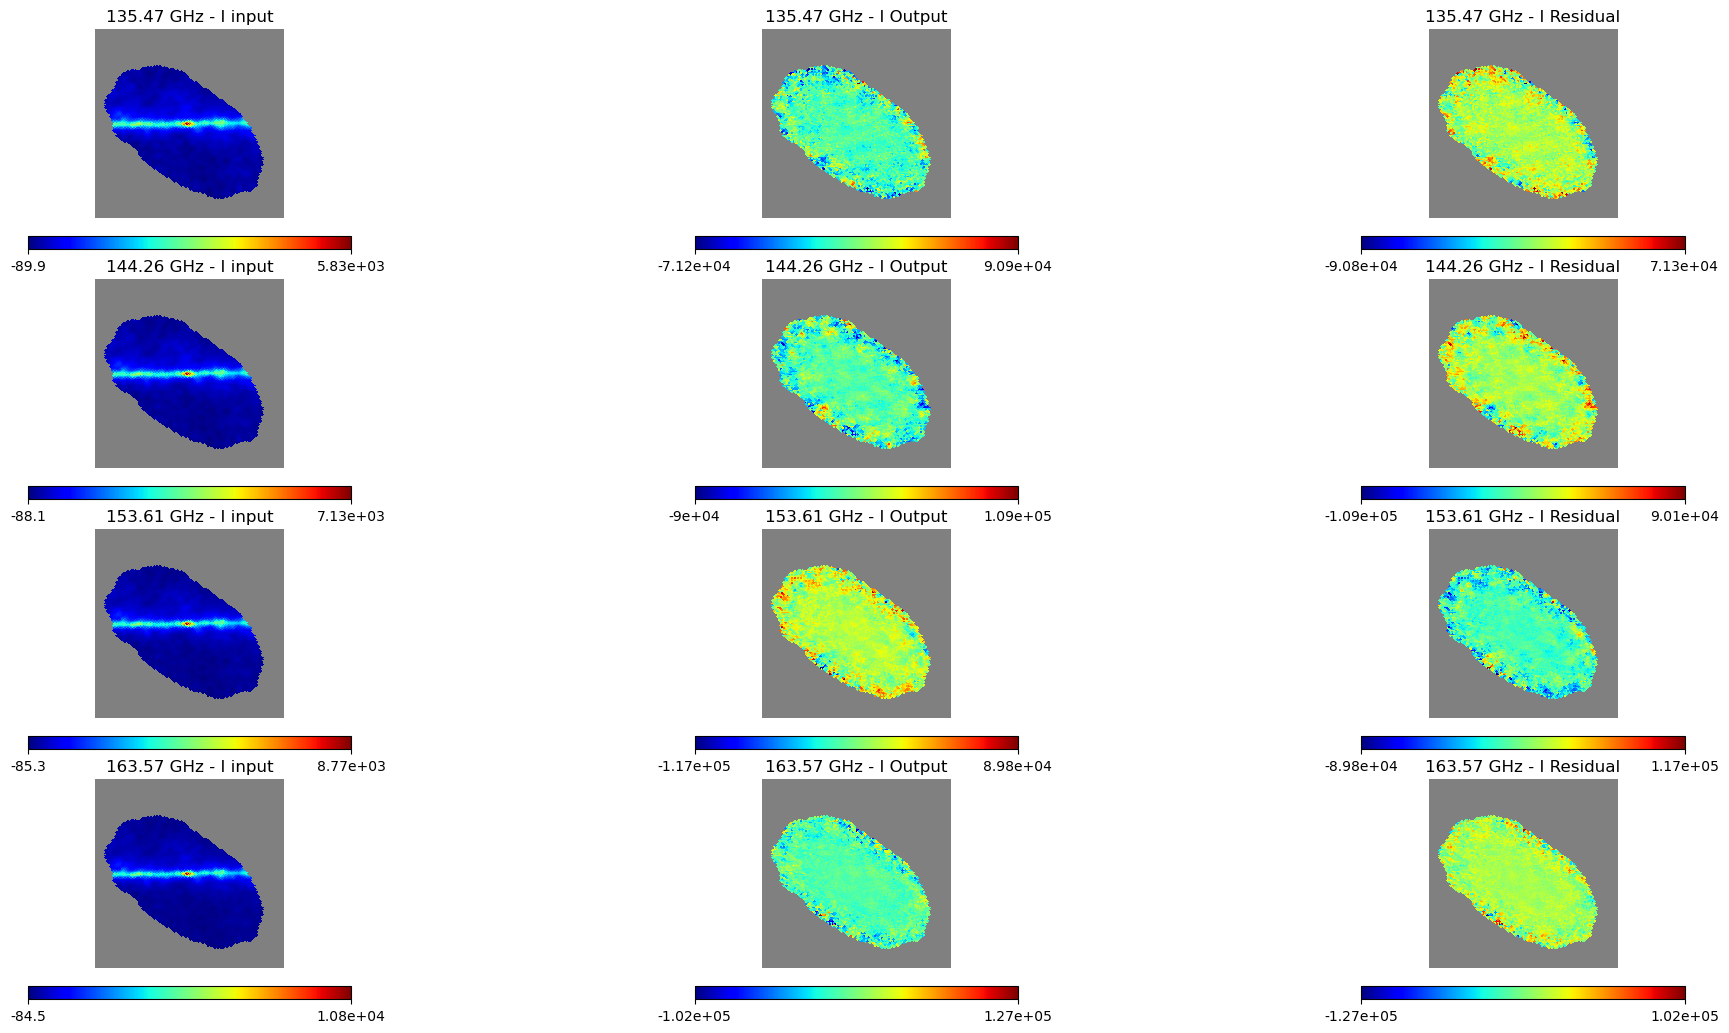

In [43]:
inspect_maps("/media/mattia/Hard Disk/data/sp_vs_ss/ss_with_hwp.pkl")

In [35]:
plt.rcParams.update({
    'font.size': 20,           # dimensione dei testi generali
    'axes.titlesize': 30,      # dimensione dei titoli degli assi
    'axes.labelsize': 16,      # dimensione delle label degli assi
    'xtick.labelsize': 25,     # dimensione dei tick x
    'ytick.labelsize': 14,     # dimensione dei tick y
})

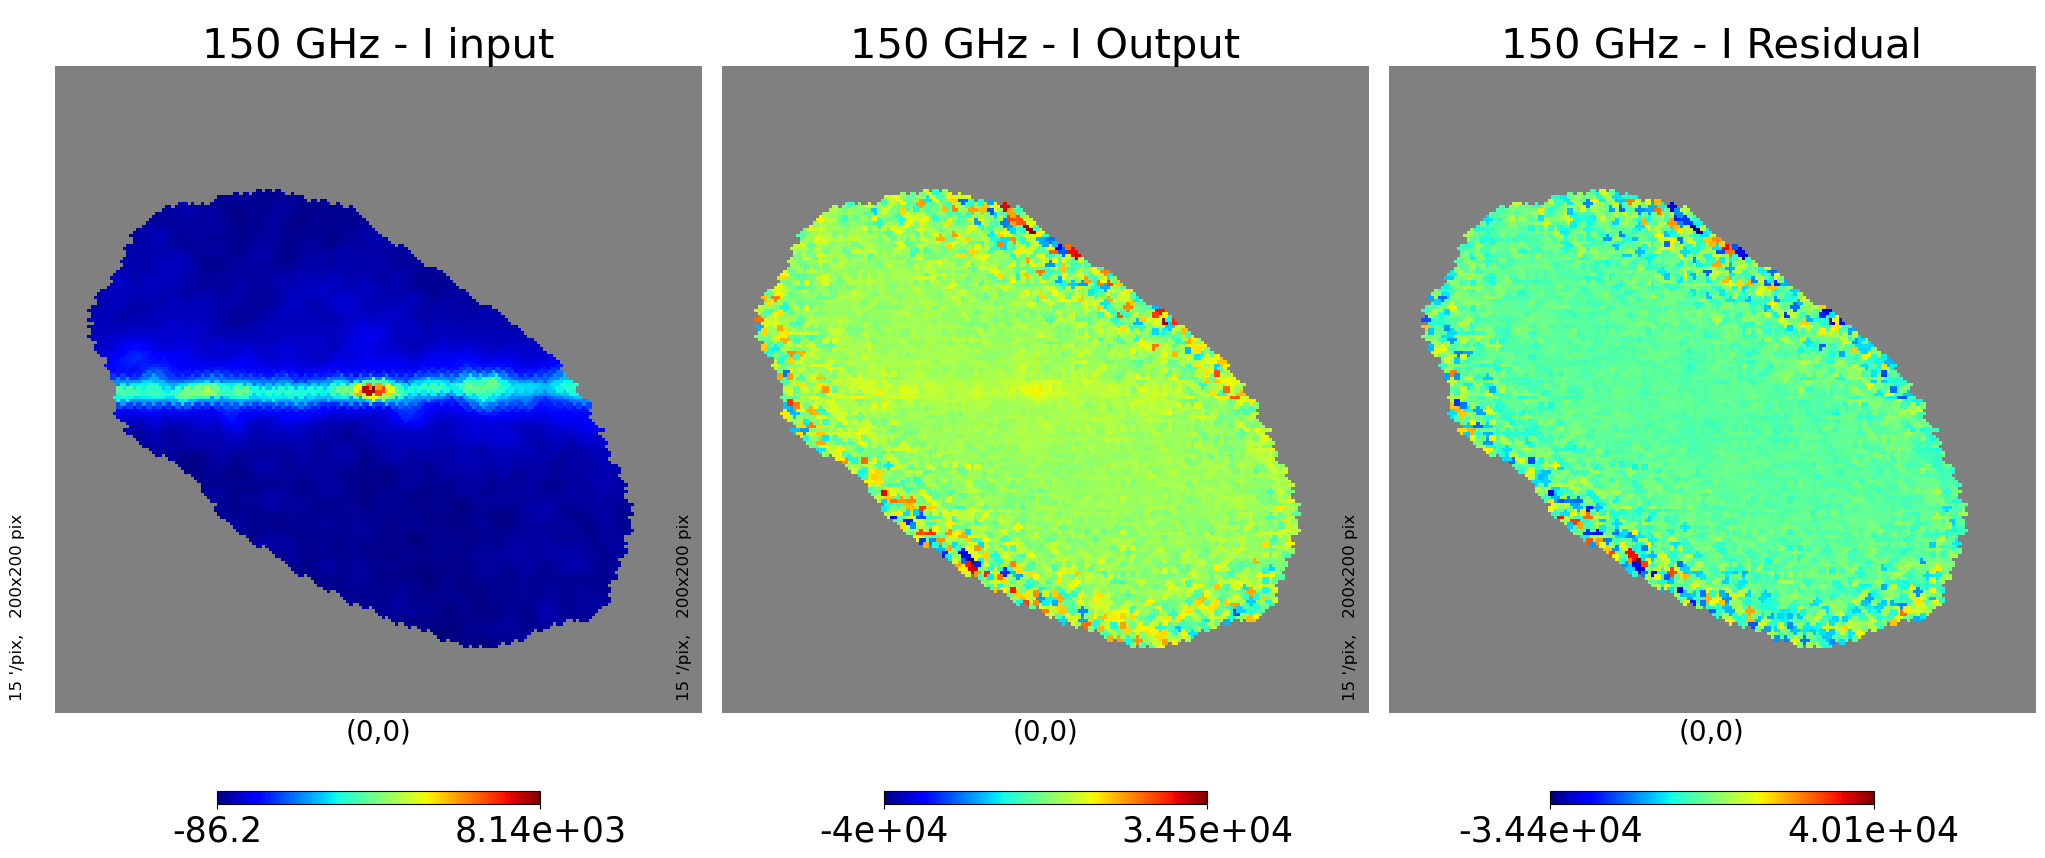

In [36]:
ss2 = load_maps("/media/mattia/Hard Disk/data/sp_vs_ss/ss_with_hwp.pkl")

maps_input_mean_ss2 = np.mean(ss2[0], axis=0)
maps_rec_mean_ss2 = np.mean(ss2[1], axis=0)
maps_res_mean_ss2 = np.mean(ss2[2], axis=0)

plt.figure(figsize=(20, 10))
#plt.title('Scanning strategy (HWP rotation)')
plt.axis('off')
hp.gnomview((maps_input_mean_ss2), rot=ss2[4],
                        reso=15,
                        notext=False,
                        title=f"150 GHz - I input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(1,3,1))
    
hp.gnomview((maps_rec_mean_ss2), rot=ss2[4],
                        reso=15,
                        notext=False,
                        title=f"150 GHz - I Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(1,3,2))


hp.gnomview((maps_res_mean_ss2), rot=ss2[4],
                        reso=15,
                        notext=False,
                        title=f"150 GHz - I Residual",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(1,3,3))

In [15]:
brightest_pix_input = np.argmax(maps_input_mean_ss2)   # indice del pixel con valore massimo nelle mappe di input
brightest_val = maps_rec_mean_ss2[brightest_pix_input]
brightest_val_true = maps_input_mean_ss2[brightest_pix_input]

#print('coverage pixel più luminoso', coverage_rp[brightest_pix_input])
print('Pixel più luminoso mappa input', brightest_val_true)
print('Pixel più luminoso mappe ricostruita', brightest_val)
print('SNR', brightest_val_true/(brightest_val-brightest_val_true))

Pixel più luminoso mappa input 8140.484210744878
Pixel più luminoso mappe ricostruita 9469.853411659991
SNR 6.123569137257818


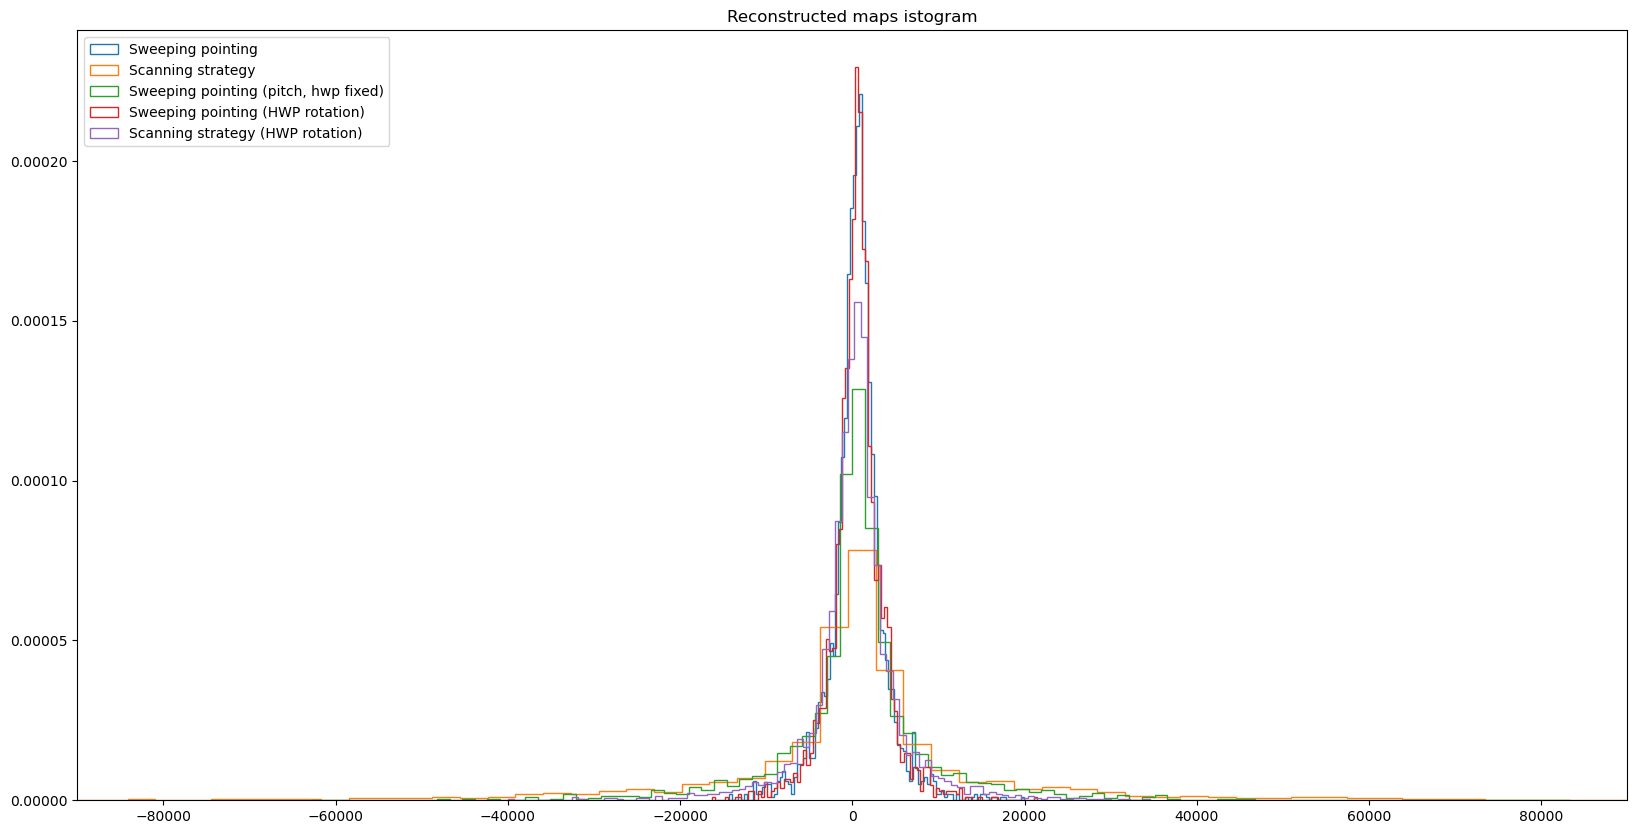

In [ ]:
plt.figure(figsize=(20,10))
plt.hist(maps_rec_mean_sp[maps_rec_mean_sp>-1e30], bins=100, histtype='step', label='Sweeping pointing', density=True)
plt.hist(maps_rec_mean_ss[maps_rec_mean_ss>-1e30], bins=100, histtype='step', label='Scanning strategy (pith, hwp fixed)', density=True)
plt.hist(maps_rec_mean_sp2[maps_rec_mean_sp2>-1e30], bins=100, histtype='step', label='Sweeping pointing (pitch, hwp fixed)', density=True)
plt.hist(maps_rec_mean_sp3[maps_rec_mean_sp3>-1e30], bins=100, histtype='step', label='Sweeping pointing (pitch fixed)', density=True)
plt.hist(maps_rec_mean_ss2[maps_rec_mean_ss2>-1e30], bins=100, histtype='step', label='Scanning strategy (pitch fixed)', density=True)
#plt.xlim(-30000,30000)
plt.xlim(-90000,90000)
#plt.ylim(0,0.0001)
plt.title('Reconstructed maps istogram')
plt.legend(loc='upper left')

In [ ]:
print('scanning strategy (pitch and hwp fixed) std:', np.std(maps_rec_mean_ss[maps_rec_mean_ss>-1e30]))
print('sweeping pointing std:', np.std(maps_rec_mean_sp[maps_rec_mean_sp>-1e30]))
print('sweeping pointing (pitch and hwp fixed) std:', np.std(maps_rec_mean_sp2[maps_rec_mean_sp2>-1e30]))
print('sweeping pointing (pitch fixed) std:', np.std(maps_rec_mean_sp3[maps_rec_mean_sp3>-1e30]))
print('scanning strategy (pitch fixed) std:', np.std(maps_rec_mean_ss2[maps_rec_mean_ss2>-1e30]))

# More one the HWP influence on the noise level

In [1]:
# hwp fissa a 90° gradi
data90 = pickle.load(open("/home/mattia/qubic/qubic/scripts/MapMaking/src/FMM/test_hwp/maps/test90_None.pkl", 'rb'))


NameError: name 'pickle' is not defined

I 66208.46296853956
Q 87717.54268024946
U 89963.48577502079


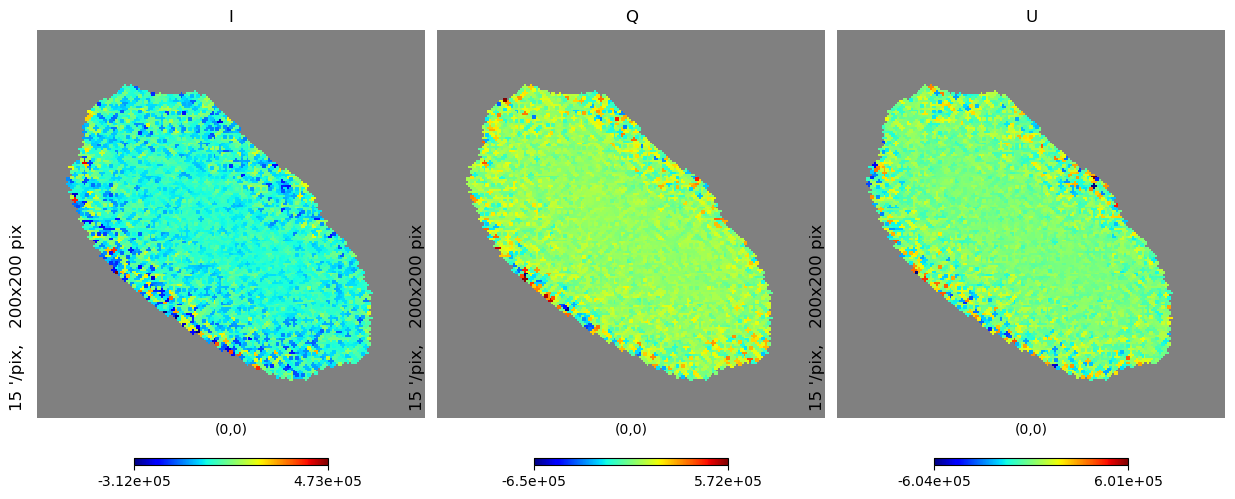

In [23]:
maps = data90["maps_noise"]
maps[:,~data90['seenpix'],:] = hp.UNSEEN
plt.figure(figsize=(12,5))
hp.gnomview(maps[0,:,0], reso=15, cmap='jet', title='I', sub=(1,3,1))
hp.gnomview(maps[0,:,1], reso=15, cmap='jet', title='Q', sub=(1,3,2))
hp.gnomview(maps[0,:,2], reso=15, cmap='jet', title='U', sub=(1,3,3))
print('I', np.std(maps[0,data90['seenpix'],0]))
print('Q', np.std(maps[0,data90['seenpix'],1]))
print('U', np.std(maps[0,data90['seenpix'],2]))

I 66201.50781511306
Q 93398.59359676643
U 84036.81576127389


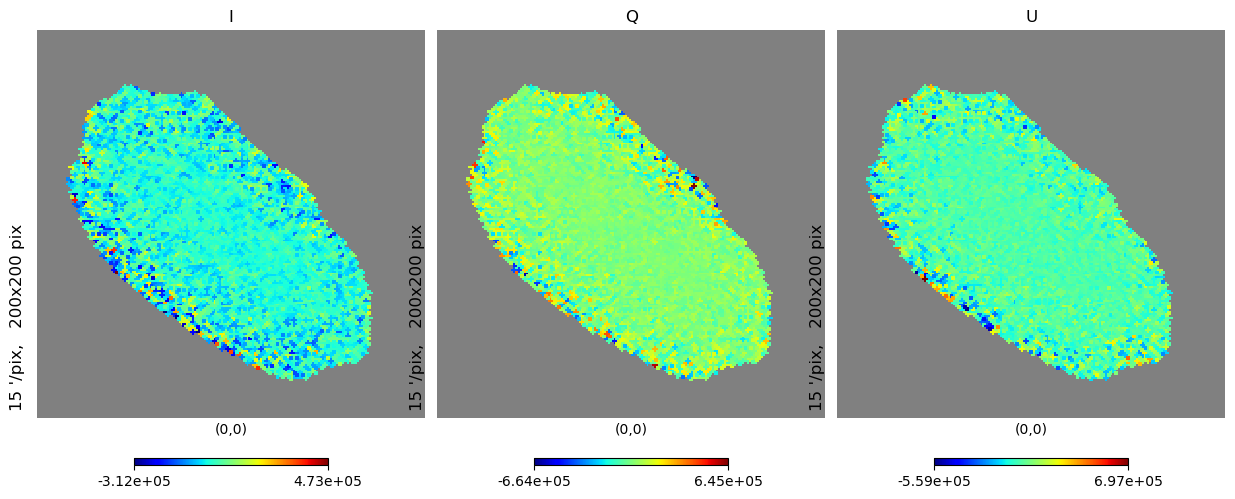

In [ ]:
# hwp fissa a 15 gradi
data15 = pickle.load(open("/home/mattia/qubic/qubic/scripts/MapMaking/src/FMM/test_hwp/maps/test0_None.pkl", 'rb'))
maps = data15["maps_noise"]
maps[:,~data15['seenpix'],:] = hp.UNSEEN
plt.figure(figsize=(12,5))
hp.gnomview(maps[0,:,0], reso=15, cmap='jet', title='I', sub=(1,3,1))
hp.gnomview(maps[0,:,1], reso=15, cmap='jet', title='Q', sub=(1,3,2))
hp.gnomview(maps[0,:,2], reso=15, cmap='jet', title='U', sub=(1,3,3))
print('I', np.std(maps[0,data15['seenpix'],0]))
print('Q', np.std(maps[0,data15['seenpix'],1]))
print('U', np.std(maps[0,data15['seenpix'],2]))


In [2]:
# hwp rotante
data = pickle.load(open("/home/mattia/qubic/qubic/scripts/MapMaking/src/FMM/test_hwp/maps/test1_None.pkl", 'rb'))
maps = data["maps_noise"]
maps[:,~data['seenpix'],:] = hp.UNSEEN
plt.figure(figsize=(12,5))
hp.gnomview(maps[0,:,0], reso=15, cmap='jet', title='I', sub=(1,3,1))
hp.gnomview(maps[0,:,1], reso=15, cmap='jet', title='Q', sub=(1,3,2))
hp.gnomview(maps[0,:,2], reso=15, cmap='jet', title='U', sub=(1,3,3))
print('I', np.std(maps[0,data['seenpix'],0]))
print('Q', np.std(maps[0,data['seenpix'],1]))
print('U', np.std(maps[0,data['seenpix'],2]))


NameError: name 'pickle' is not defined

In [27]:
hwp_rotante = pickle.load(open("/media/mattia/Hard Disk/data/center/maps/01-02_ss_hwp.pkl", 'rb'))
hwp_fissa = pickle.load(open("/media/mattia/Hard Disk/data/center/maps/01-02_planck.pkl", 'rb'))

I 4071.3399766766834
Q 4890.128850904984
U 4974.7104773527635


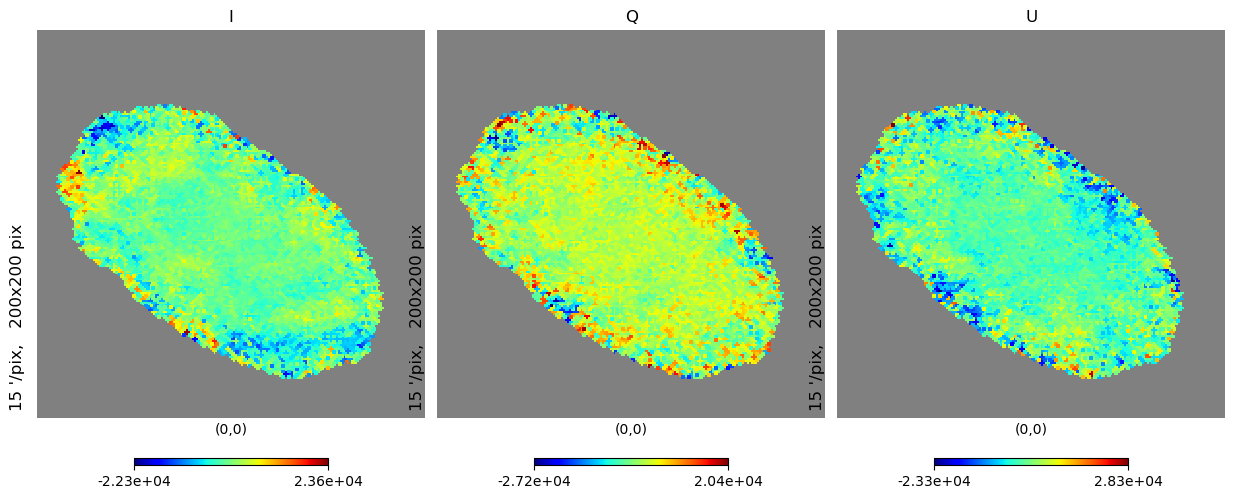

In [28]:
maps = hwp_rotante["maps_noise"]
maps[:,~hwp_rotante['seenpix'],:] = hp.UNSEEN
plt.figure(figsize=(12,5))
hp.gnomview(maps[0,:,0], reso=15, cmap='jet', title='I', sub=(1,3,1))
hp.gnomview(maps[0,:,1], reso=15, cmap='jet', title='Q', sub=(1,3,2))
hp.gnomview(maps[0,:,2], reso=15, cmap='jet', title='U', sub=(1,3,3))
print('I', np.std(maps[0,hwp_rotante['seenpix'],0]))
print('Q', np.std(maps[0,hwp_rotante['seenpix'],1]))
print('U', np.std(maps[0,hwp_rotante['seenpix'],2]))

I 13294.223137507337
Q 11479.454117445788
U 12025.678016796677


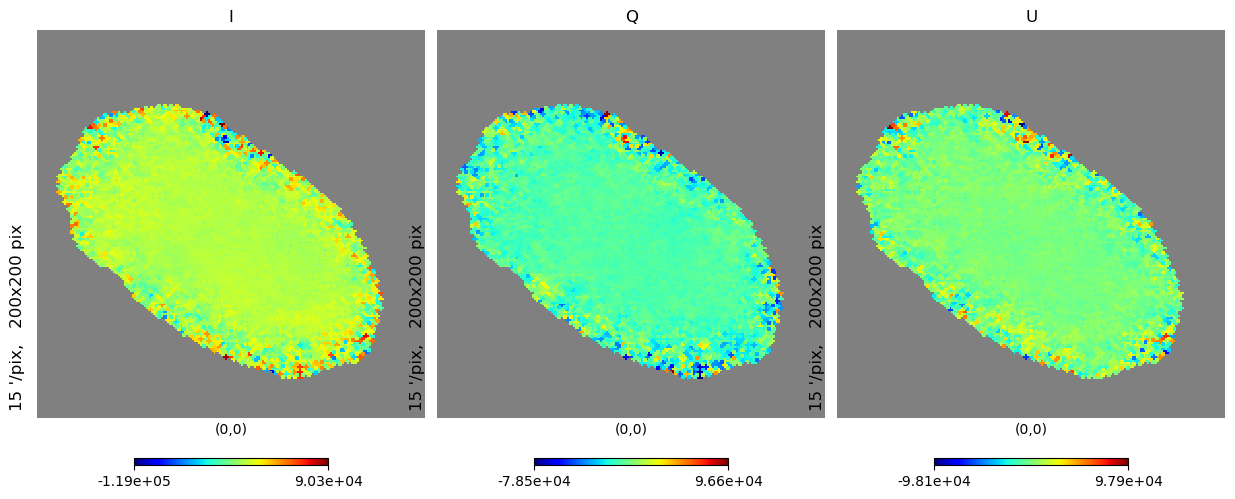

In [30]:
maps = hwp_fissa["maps_noise"]
maps[:,~hwp_fissa['seenpix'],:] = hp.UNSEEN
plt.figure(figsize=(12,5))
hp.gnomview(maps[0,:,0], reso=15, cmap='jet', title='I', sub=(1,3,1))
hp.gnomview(maps[0,:,1], reso=15, cmap='jet', title='Q', sub=(1,3,2))
hp.gnomview(maps[0,:,2], reso=15, cmap='jet', title='U', sub=(1,3,3))
print('I', np.std(maps[0,hwp_fissa['seenpix'],0]))
print('Q', np.std(maps[0,hwp_fissa['seenpix'],1]))
print('U', np.std(maps[0,hwp_fissa['seenpix'],2]))